# NDTA 631 — Group Assignment: Has South Africa's Digital Economy Improved Enough to Support AI Adoption?

**Research question:** Has South Africa's digital economy improved enough to support AI adoption?

This notebook combines the group's full work, in the following order:

1. **Data Preparation & Numerical Analysis** — IMF AI Preparedness dataset
2. **Data Preparation & Numerical Analysis** — UNCTAD Digital Economy dataset
3. **Visualisation** — both IMF AI Preparedness and UNCTAD Digital Economy
4. **Database Integration** — combining both cleaned datasets in a SQLite database
5. **Python/Excel Data Analysis** — pivot tables, conditional formatting, and additional charts

GROUP NAMES <br>
Masiphile Zwane-202400528<br>
Lesedi Moseri-202342368<br>
Yvann Massoukou-202413207<br>
Tshepo Mogakane-202410894<br>
Ntlhari Godi - 202310915<br>
Tebatso Madisha - 202416636<br>
Samkelisiwe Biyela - 202412263<br>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---

# Part 1: IMF AI Preparedness Dataset — Data Preparation & Numerical Analysis

Data cleaning, descriptive statistics, and NumPy-based numerical analysis for South Africa's AI Preparedness indicators (2023).

# Data Understanding:

This dataset contains AI Preparedness indicators for different countries. The analysis focuses on South Africa, for which the available AI preparedness data is from 2023. The selected indicators will be used together with the Digital Economy dataset to answer the research question:

>  Has South Africa's digital economy improved enough to support AI adoption?

In [ ]:
# Import the libraries required for data analysis

import pandas as pd
import numpy as np

In [ ]:
import pandas as pd
import numpy as np

# Load the IMF AI dataset into a Pandas DataFrame and perform cleaning
try:
    df = pd.read_csv("/IMF_AI.csv")
    print("Raw IMF AI dataset loaded successfully.")

    # choosing only the columns needed for analysis
    df = df[
        [
            "REF_AREA_LABEL",
            "TIME_PERIOD",
            "INDICATOR_LABEL",
            "OBS_VALUE"
        ]
    ]

    # removes extra spaces from country names
    df["REF_AREA_LABEL"] = df["REF_AREA_LABEL"].str.strip()

    # Filter the dataset to include only South Africa
    df = df[df["REF_AREA_LABEL"] == "South Africa"]

    # Remove duplicate records
    duplicates_before = df.shape[0]
    df = df.drop_duplicates()
    duplicates_after = df.shape[0]
    if duplicates_before > duplicates_after:
        print(f"Removed {duplicates_before - duplicates_after} duplicate records.")

    # Remove rows containing missing values
    rows_before_dropna = df.shape[0]
    df = df.dropna()
    rows_after_dropna = df.shape[0]
    if rows_before_dropna > rows_after_dropna:
        print(f"Removed {rows_before_dropna - rows_after_dropna} rows with missing values.")

    print("IMF AI data cleaned and filtered for South Africa.")
    print("Cleaned IMF AI data head:")
    print(df.head())
    print("Cleaned IMF AI data shape:", df.shape)

except FileNotFoundError:
    print("Error: /IMF_AI.csv was not found. Please ensure the file is uploaded to the root directory.")
except Exception as e:
    print("Error loading or cleaning the IMF AI dataset:", e)

Raw IMF AI dataset loaded successfully.
IMF AI data cleaned and filtered for South Africa.
Cleaned IMF AI data head:
    REF_AREA_LABEL  TIME_PERIOD  \
163   South Africa         2023   
337   South Africa         2023   
511   South Africa         2023   
679   South Africa         2023   
854   South Africa         2023   

                                    INDICATOR_LABEL  OBS_VALUE  
163                    AI Preparedness Index (AIPI)   0.496765  
337                   AIPI - Digital Infrastructure   0.123994  
511  AIPI - Human Capital and Labor Market Policies   0.119912  
679      AIPI - Innovation and Economic Integration   0.110192  
854                    AIPI - Regulation and Ethics   0.142667  
Cleaned IMF AI data shape: (5, 4)


In [ ]:
# Display the first five rows of the dataset
df.head()

,REF_AREA_LABEL,TIME_PERIOD,INDICATOR_LABEL,OBS_VALUE
163,South Africa,2023,AI Preparedness Index (AIPI),0.496765
337,South Africa,2023,AIPI - Digital Infrastructure,0.123994
511,South Africa,2023,AIPI - Human Capital and Labor Market Policies,0.119912
679,South Africa,2023,AIPI - Innovation and Economic Integration,0.110192
854,South Africa,2023,AIPI - Regulation and Ethics,0.142667


In [ ]:
# Display the number of rows and columns in the dataset
print("Rows and Columns:", df.shape)

Rows and Columns: (5, 4)


In [ ]:
# Display all column names in the dataset
print(df.columns)

Index(['REF_AREA_LABEL', 'TIME_PERIOD', 'INDICATOR_LABEL', 'OBS_VALUE'], dtype='object')


In [ ]:
# Display the structure of the dataset, data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 163 to 854
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   REF_AREA_LABEL   5 non-null      object 
 1   TIME_PERIOD      5 non-null      int64  
 2   INDICATOR_LABEL  5 non-null      object 
 3   OBS_VALUE        5 non-null      float64
dtypes: float64(1), int64(1), object(2)
memory usage: 200.0+ bytes


In [ ]:
# Check for duplicate records

duplicates = df.duplicated().sum()
print("Duplicate records:", duplicates)

Duplicate records: 0


In [ ]:
# This cell's content has been moved to the initial loading cell for consolidated cleaning.
# The 'df' DataFrame is already cleaned and filtered at this point.
# Verify that duplicates have been removed (should be 0):
print("Duplicate records after cleaning:", df.duplicated().sum())


Duplicate records after cleaning: 0


In [ ]:
# Verify that duplicates have been removed

print("Duplicate records after cleaning:", df.duplicated().sum())

Duplicate records after cleaning: 0


In [ ]:
# Display all AI indicators available in the dataset
for indicator in df["INDICATOR_LABEL"].unique():
    print(indicator)

AI Preparedness Index (AIPI)
AIPI - Digital Infrastructure
AIPI - Human Capital and Labor Market Policies
AIPI - Innovation and Economic Integration
AIPI - Regulation and Ethics


In [ ]:
# This cell's content has been moved to the previous loading cell for consolidated cleaning.
# The 'df' DataFrame is already cleaned and filtered at this point.
# Displaying the first rows of the cleaned data:
df.head()


,REF_AREA_LABEL,TIME_PERIOD,INDICATOR_LABEL,OBS_VALUE
163,South Africa,2023,AI Preparedness Index (AIPI),0.496765
337,South Africa,2023,AIPI - Digital Infrastructure,0.123994
511,South Africa,2023,AIPI - Human Capital and Labor Market Policies,0.119912
679,South Africa,2023,AIPI - Innovation and Economic Integration,0.110192
854,South Africa,2023,AIPI - Regulation and Ethics,0.142667


In [ ]:
# Displaying the first rows
df.head()

,REF_AREA_LABEL,TIME_PERIOD,INDICATOR_LABEL,OBS_VALUE
163,South Africa,2023,AI Preparedness Index (AIPI),0.496765
337,South Africa,2023,AIPI - Digital Infrastructure,0.123994
511,South Africa,2023,AIPI - Human Capital and Labor Market Policies,0.119912
679,South Africa,2023,AIPI - Innovation and Economic Integration,0.110192
854,South Africa,2023,AIPI - Regulation and Ethics,0.142667


In [ ]:
# This cell's content has been moved to the initial loading cell for consolidated cleaning.
# The 'df' DataFrame is already cleaned and filtered at this point.
# Display all countries available in the dataset (should only be South Africa now):
print(df["REF_AREA_LABEL"].unique())


['South Africa']


In [ ]:
# Display all countries available in the dataset
print(df["REF_AREA_LABEL"].unique())

['South Africa']


In [ ]:
# This cell's content has been moved to the initial loading cell for consolidated cleaning.
# The 'df' DataFrame is already cleaned and filtered at this point.
# Verify that only South Africa remains:
print(df["REF_AREA_LABEL"].unique())


['South Africa']


In [ ]:
# Verify that only South Africa remains
print(df["REF_AREA_LABEL"].unique())

['South Africa']


In [ ]:
# Check for missing values in each column

print(df.isnull().sum())

REF_AREA_LABEL     0
TIME_PERIOD        0
INDICATOR_LABEL    0
OBS_VALUE          0
dtype: int64


In [ ]:

# This cell's content has been moved to the initial loading cell for consolidated cleaning.
# The 'df' DataFrame is already cleaned and filtered at this point.
# Check for missing values in each column (should be 0 for selected columns):
print(df.isnull().sum())


REF_AREA_LABEL     0
TIME_PERIOD        0
INDICATOR_LABEL    0
OBS_VALUE          0
dtype: int64


In [ ]:
# Check and display the first five rows of the dataset with only South Africa
df.head()

,REF_AREA_LABEL,TIME_PERIOD,INDICATOR_LABEL,OBS_VALUE
163,South Africa,2023,AI Preparedness Index (AIPI),0.496765
337,South Africa,2023,AIPI - Digital Infrastructure,0.123994
511,South Africa,2023,AIPI - Human Capital and Labor Market Policies,0.119912
679,South Africa,2023,AIPI - Innovation and Economic Integration,0.110192
854,South Africa,2023,AIPI - Regulation and Ethics,0.142667


In [ ]:
# checking null values
print(df.isnull().sum())

REF_AREA_LABEL     0
TIME_PERIOD        0
INDICATOR_LABEL    0
OBS_VALUE          0
dtype: int64


In [ ]:
# check the size of rows and columns
print(df.shape)

(5, 4)


In [ ]:
# Displaying years available in the dataset
print(df["TIME_PERIOD"].unique())

[2023]


In [ ]:
# Displaying available indicators in the dataset
print(df["INDICATOR_LABEL"].unique())

['AI Preparedness Index (AIPI)' 'AIPI - Digital Infrastructure'
 'AIPI - Human Capital and Labor Market Policies'
 'AIPI - Innovation and Economic Integration'
 'AIPI - Regulation and Ethics']


In [ ]:
# Generate descriptive statistics for the AI preparedness scores
# (TIME_PERIOD is not analysed here since every remaining row is 2023)
df["OBS_VALUE"].describe()

,OBS_VALUE
count,5.000000
mean,0.198706
std,0.167036
min,0.110192
25%,0.119912
50%,0.123994
75%,0.142667
max,0.496765


INSIGHTS

1. After cleaning and filtering, the dataset contains 5 records and 4 relevant columns for South Africa (starting from a raw dataset of 857 records and 40 columns covering all countries). Each of the 5 records represents one AI preparedness indicator for 2023.
2. South Africa only has one year of data available in this dataset: 2023. This dataset alone cannot be used to measure improvement in AI preparedness over time; it only provides a single-year snapshot.
3. No missing values were found in the four selected variables for South Africa, so no missing-value imputation was necessary.
4. The dataset contains one overall index and four component indicators for South Africa:

- AI Preparedness Index (AIPI) - overall score: 0.496765
- AIPI - Regulation and Ethics: 0.142667 (highest-scoring component)
- AIPI - Digital Infrastructure: 0.123994
- AIPI - Human Capital and Labor Market Policies: 0.119912
- AIPI - Innovation and Economic Integration: 0.110192 (lowest-scoring component)

5. Among the four component indicators, Regulation and Ethics is South Africa's strongest area and Innovation and Economic Integration is its weakest. The overall AIPI score (0.497) is naturally higher than any single component since it is an aggregate of all four, not a fifth comparable dimension, so it is reported separately rather than ranked alongside the components.
6. This IMF AI dataset only provides South Africa's AI preparedness position in 2023, not evidence of change over time. Answering the group's research question, "Has South Africa's digital economy improved enough to support AI adoption?", requires combining this snapshot with the Digital Economy dataset, which is expected to show whether digital infrastructure has improved over multiple years.

In [ ]:
df.to_csv("/content/IMF_AI_Cleaned.csv", index=False)

print("Cleaned IMF AI dataset saved successfully to /content/IMF_AI_Cleaned.csv.")


Cleaned IMF AI dataset saved successfully to /content/IMF_AI_Cleaned.csv.


# 2. Numerical Analysis

## Extract the numerical values
### 2.1 Convert Indicator Values to a NumPy Array

The observation values are extracted from the cleaned dataset and
converted into a NumPy array so that numerical operations can be
performed.

In [ ]:
# Extract observation values and convert them to a NumPy array
values = df["OBS_VALUE"].to_numpy()

print("NumPy array:")
print(values)

print("\nArray shape:", values.shape)

NumPy array:
[0.49676514 0.12399416 0.11991155 0.11019237 0.14266707]

Array shape: (5,)


### Basic NumPy calculations

We calculate:

Mean
Median
Minimum
Maximum
Standard deviation
Range


In [ ]:
# Calculate descriptive statistics using NumPy
mean_value = np.mean(values)
median_value = np.median(values)
minimum_value = np.min(values)
maximum_value = np.max(values)
std_value = np.std(values)
range_value = np.ptp(values)

print("Mean:", mean_value)
print("Median:", median_value)
print("Minimum:", minimum_value)
print("Maximum:", maximum_value)
print("Standard deviation:", std_value)
print("Range:", range_value)

Mean: 0.198706057667732
Median: 0.12399415671825
Minimum: 0.11019236594439
Maximum: 0.49676514416933
Standard deviation: 0.14940194319589847
Range: 0.38657277822493996


### 2.2 Calculate Indicator-Level Performance

The mean score for each AI preparedness indicator is calculated
to compare the different dimensions of South Africa's AI readiness.

In [ ]:
# Calculate the mean score for each AI preparedness indicator
indicator_means = (
    df.groupby("INDICATOR_LABEL")["OBS_VALUE"]
    .mean()
    .sort_values(ascending=False)
)

print(indicator_means)

INDICATOR_LABEL
AI Preparedness Index (AIPI)                      0.496765
AIPI - Regulation and Ethics                      0.142667
AIPI - Digital Infrastructure                     0.123994
AIPI - Human Capital and Labor Market Policies    0.119912
AIPI - Innovation and Economic Integration        0.110192
Name: OBS_VALUE, dtype: float64


**Note:** `AI Preparedness Index (AIPI)` is the overall aggregate score, while the remaining four indicators (Digital Infrastructure, Human Capital and Labor Market Policies, Innovation and Economic Integration, Regulation and Ethics) are its component dimensions. Comparing the overall index against its own components is not a fair comparison, so the analysis below separates them: the overall AIPI is reported on its own, and the highest/lowest, gap, reshape, and normalisation calculations that follow use only the four component indicators.

In [ ]:
# Separate the overall AIPI score from its four component indicators
component_means = indicator_means.drop("AI Preparedness Index (AIPI)")

overall_aipi_score = indicator_means["AI Preparedness Index (AIPI)"]

print("Overall AI Preparedness Index (AIPI):", overall_aipi_score)
print("\nComponent indicators only:")
print(component_means)

Overall AI Preparedness Index (AIPI): 0.49676514416933

Component indicators only:
INDICATOR_LABEL
AIPI - Regulation and Ethics                      0.142667
AIPI - Digital Infrastructure                     0.123994
AIPI - Human Capital and Labor Market Policies    0.119912
AIPI - Innovation and Economic Integration        0.110192
Name: OBS_VALUE, dtype: float64


In [ ]:
# Prepare component indicator scores for numerical analysis

component_scores = component_means.to_numpy()

highest_index = np.argmax(component_scores)
lowest_index = np.argmin(component_scores)

component_names = component_means.index.to_numpy()

print("Highest-scoring component indicator:")
print(component_names[highest_index])
print("Score:", component_scores[highest_index])

print("\nLowest-scoring component indicator:")
print(component_names[lowest_index])
print("Score:", component_scores[lowest_index])

Highest-scoring component indicator:
AIPI - Regulation and Ethics
Score: 0.14266707003117

Lowest-scoring component indicator:
AIPI - Innovation and Economic Integration
Score: 0.11019236594439


In [ ]:
# Calculate the difference between the highest and lowest component indicator scores
performance_gap = (
    component_scores[highest_index] - component_scores[lowest_index]
)

print("Performance gap:", performance_gap)

Performance gap: 0.03247470408677999


In [ ]:
# Calculate percentage difference between the highest and lowest components
percentage_gap = (
    performance_gap / component_scores[lowest_index]
) * 100

print("Percentage gap:", percentage_gap, "%")

Percentage gap: 29.47092006643071 %


### 2.3 Reshape the NumPy Array

The four component indicator scores (excluding the overall AIPI) are
reshaped into a two-dimensional array. This demonstrates how NumPy
arrays can be reorganised for numerical analysis.

In [ ]:
# Reshape the component indicator scores into a 2D array
scores_2d = component_scores.reshape(-1, 1)

print("Original shape:", component_scores.shape)
print("Reshaped shape:", scores_2d.shape)

print("\nReshaped array:")
print(scores_2d)

Original shape: (4,)
Reshaped shape: (4, 1)

Reshaped array:
[[0.14266707]
 [0.12399416]
 [0.11991155]
 [0.11019237]]


### Perform array operations

In [ ]:
# Calculate the overall average of the four component indicators
overall_mean = np.mean(component_scores)

# Calculate each component's difference from that average
difference_from_mean = scores_2d - overall_mean

print("Average of the four component indicators:", overall_mean)

print("\nDifference from that average:")
print(difference_from_mean)

Average of the four component indicators: 0.12419128604233251

Difference from that average:
[[ 0.01847578]
 [-0.00019713]
 [-0.00427973]
 [-0.01399892]]


In [ ]:
# Classify component indicators as above or below the component average
performance = np.where(
    component_scores >= overall_mean,
    "Above Average",
    "Below Average"
)

# Display the results
for indicator, score, category in zip(
    component_names,
    component_scores,
    performance
):
    print(f"{indicator}: {score:.3f} - {category}")

AIPI - Regulation and Ethics: 0.143 - Above Average
AIPI - Digital Infrastructure: 0.124 - Below Average
AIPI - Human Capital and Labor Market Policies: 0.120 - Below Average
AIPI - Innovation and Economic Integration: 0.110 - Below Average


### 2.4 Normalise Indicator Scores

Min-max normalisation is applied to the four component indicator
scores (excluding the overall AIPI) to place them on a common scale
between 0 and 1. This makes relative performance across the
components easier to compare.

** The formula is: **

Normalised value =
(value - minimum) / (maximum - minimum)

In [ ]:
# Find minimum and maximum component indicator scores
min_score = np.min(component_scores)
max_score = np.max(component_scores)

# Apply min-max normalisation
normalised_scores = (
    (component_scores - min_score) /
    (max_score - min_score)
)

print("Normalised scores:")
for indicator, score in zip(component_names, normalised_scores):
    print(f"{indicator}: {score:.3f}")

Normalised scores:
AIPI - Regulation and Ethics: 1.000
AIPI - Digital Infrastructure: 0.425
AIPI - Human Capital and Labor Market Policies: 0.299
AIPI - Innovation and Economic Integration: 0.000


In [ ]:
# Create a summary DataFrame for the four component indicators
numerical_summary = pd.DataFrame({
    "Indicator": component_names,
    "Mean Score": component_scores,
    "Difference from Mean": difference_from_mean.flatten(),
    "Normalised Score": normalised_scores,
    "Performance": performance
})

print("Overall AI Preparedness Index (AIPI), reported separately:", overall_aipi_score)
numerical_summary

Overall AI Preparedness Index (AIPI), reported separately: 0.49676514416933


,Indicator,Mean Score,Difference from Mean,Normalised Score,Performance
0,AIPI - Regulation and Ethics,0.142667,0.018476,1.000000,Above Average
1,AIPI - Digital Infrastructure,0.123994,-0.000197,0.425001,Below Average
2,AIPI - Human Capital and Labor Market Policies,0.119912,-0.004280,0.299285,Below Average
3,AIPI - Innovation and Economic Integration,0.110192,-0.013999,0.000000,Below Average


## FINDINGS

The numerical analysis shows that South Africa's overall AI Preparedness Index (AIPI) score is 0.496765 for 2023. The four component indicators have an average score of approximately 0.1242. Among these components, Regulation and Ethics is the strongest-performing area, with a score of 0.142667, while Innovation and Economic Integration is the weakest, with a score of 0.110192.

The difference between the highest and lowest component scores is 0.032475, representing approximately a 29.47% difference relative to the lowest component. This shows that the performance of the four AI preparedness dimensions is not evenly distributed.

Regulation and Ethics is the only component performing above the four-component average. Digital Infrastructure is very close to the average, while Human Capital and Labour Market Policies and Innovation and Economic Integration fall below the average. This suggests that regulation and ethics is a relative strength, whereas innovation and economic integration is the main area of weakness among the measured dimensions.

The NumPy array was also reshaped from a one-dimensional shape of (4,) to a two-dimensional shape of (4, 1), demonstrating the use of array reshaping for numerical analysis. The difference-from-average operation further showed how each component compares with the overall component average.

Min-max normalisation produced scores ranging from 0 to 1. Regulation and Ethics received a normalised score of 1.000, while Innovation and Economic Integration received 0.000. Digital Infrastructure and Human Capital and Labour Market Policies received 0.425 and 0.299, respectively. These results confirm the relative differences between the four components.

Overall, the numerical analysis indicates that South Africa has uneven AI preparedness across the four measured dimensions, with Regulation and Ethics performing relatively strongly and Innovation and Economic Integration requiring greater attention. However, because the dataset contains only 2023 AI preparedness data, these results show South Africa's position for that year rather than improvement over time. Therefore, the numerical analysis alone cannot determine whether South Africa's digital economy has improved enough to support AI adoption. This requires comparison with the Digital Economy dataset.

---

# Part 2: UNCTAD Digital Economy Dataset — Data Preparation & Numerical Analysis

Data cleaning and NumPy-based numerical analysis for South Africa's Digital Economy indicators (2010-2023).

Data Understanding:

This dataset contains Digital Economy indicators for different countries over multiple years (2010-2023). Unlike the IMF AI dataset, which only contains 2023 data, this dataset contains many years for South Africa, so it can be used to show how South Africa's digital economy has changed over time. The selected indicators will be used together with the IMF AI Preparedness dataset to answer the research question:

> Has South Africa's digital economy improved enough to support AI adoption?

In [ ]:
# Import the libraries required for data analysis

import pandas as pd
import numpy as np

In [ ]:
import pandas as pd
import numpy as np

# Load the UNCTAD Digital Economy dataset into a Pandas DataFrame and perform cleaning
try:
    # Load the raw UNCTAD data file with the correct path and name (without space, as selected)
    df_unctad = pd.read_csv("/UNCTAD_DE.csv")
    print("Raw UNCTAD Digital Economy dataset loaded successfully from /UNCTAD_DE.csv.")

    # choosing only the columns needed for analysis
    df_unctad = df_unctad[
        [
            "REF_AREA_LABEL",
            "TIME_PERIOD",
            "INDICATOR_LABEL",
            "UNIT_MEASURE_LABEL", # This column is expected in the raw UNCTAD data
            "OBS_VALUE"
        ]
    ]

    # removes extra spaces from country names
    df_unctad["REF_AREA_LABEL"] = df_unctad["REF_AREA_LABEL"].str.strip()

    # standardise text formatting for country names
    df_unctad["REF_AREA_LABEL"] = df_unctad["REF_AREA_LABEL"].str.title()

    # Filter the dataset to include only South Africa
    df_unctad = df_unctad[df_unctad["REF_AREA_LABEL"] == "South Africa"]

    # Remove duplicate records
    duplicates_before = df_unctad.shape[0]
    df_unctad = df_unctad.drop_duplicates()
    duplicates_after = df_unctad.shape[0]
    if duplicates_before > duplicates_after:
        print(f"Removed {duplicates_before - duplicates_after} duplicate records.")

    # Remove rows containing missing values
    rows_before_dropna = df_unctad.shape[0]
    df_unctad = df_unctad.dropna()
    rows_after_dropna = df_unctad.shape[0]
    if rows_before_dropna > rows_after_dropna:
        print(f"Removed {rows_before_dropna - rows_after_dropna} rows with missing values.")

    print("UNCTAD Digital Economy data cleaned and filtered for South Africa.")
    print("Cleaned UNCTAD DE data head:")
    print(df_unctad.head())
    print("Cleaned UNCTAD DE data shape:", df_unctad.shape)

except FileNotFoundError:
    print("Error: /UNCTAD_DE.csv was not found. Please ensure the raw file is uploaded to the root directory.")
except KeyError as e:
    print(f"Error: A required column was not found. This often means the wrong file was loaded or the file is corrupted. Details: {e}")
except Exception as e:
    print("Error loading or cleaning the UNCTAD Digital Economy dataset:", e)

Raw UNCTAD Digital Economy dataset loaded successfully from /UNCTAD_DE.csv.
UNCTAD Digital Economy data cleaned and filtered for South Africa.
Cleaned UNCTAD DE data head:
     REF_AREA_LABEL  TIME_PERIOD  \
2380   South Africa         2010   
2381   South Africa         2011   
2382   South Africa         2012   
2383   South Africa         2013   
2384   South Africa         2014   

                                        INDICATOR_LABEL UNIT_MEASURE_LABEL  \
2380  International exports in digitally-deliverable...         US dollars   
2381  International exports in digitally-deliverable...         US dollars   
2382  International exports in digitally-deliverable...         US dollars   
2383  International exports in digitally-deliverable...         US dollars   
2384  International exports in digitally-deliverable...         US dollars   

      OBS_VALUE  
2380     3890.0  
2381     4664.0  
2382     4936.0  
2383     4927.0  
2384     5145.0  
Cleaned UNCTAD DE data shape: (55,

In [ ]:
# Display the first five rows of the dataset
df.head()

,REF_AREA_LABEL,TIME_PERIOD,INDICATOR_LABEL,OBS_VALUE
0,South Africa,2023,AI Preparedness Index (AIPI),0.496765
1,South Africa,2023,AIPI - Digital Infrastructure,0.123994
2,South Africa,2023,AIPI - Human Capital and Labor Market Policies,0.119912
3,South Africa,2023,AIPI - Innovation and Economic Integration,0.110192
4,South Africa,2023,AIPI - Regulation and Ethics,0.142667


In [ ]:
# Display the number of rows and columns in the dataset
print("Rows and Columns:", df.shape)

Rows and Columns: (5, 4)


In [ ]:
# Display all column names in the dataset
print(df.columns)

Index(['REF_AREA_LABEL', 'TIME_PERIOD', 'INDICATOR_LABEL', 'OBS_VALUE'], dtype='object')


In [ ]:
# Display the structure of the dataset, data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   REF_AREA_LABEL   5 non-null      object 
 1   TIME_PERIOD      5 non-null      int64  
 2   INDICATOR_LABEL  5 non-null      object 
 3   OBS_VALUE        5 non-null      float64
dtypes: float64(1), int64(1), object(2)
memory usage: 292.0+ bytes


In [ ]:
# Check for duplicate records

duplicates = df.duplicated().sum()
print("Duplicate records:", duplicates)

Duplicate records: 0


In [ ]:
# This cell's content has been moved to the initial loading cell for consolidated cleaning.
# The 'df' DataFrame is already cleaned and filtered at this point.
# Verify that duplicates have been removed (should be 0):
print("Duplicate records after cleaning:", df.duplicated().sum())


Duplicate records after cleaning: 0


In [ ]:
# Verify that duplicates have been removed

print("Duplicate records after cleaning:", df.duplicated().sum())

Duplicate records after cleaning: 0


In [ ]:
# Display all Digital Economy indicators available in the dataset
for indicator in df["INDICATOR_LABEL"].unique():
    print(indicator)

AI Preparedness Index (AIPI)
AIPI - Digital Infrastructure
AIPI - Human Capital and Labor Market Policies
AIPI - Innovation and Economic Integration
AIPI - Regulation and Ethics


In [ ]:
# This cell's content has been moved to the previous loading cell for consolidated cleaning.
# The 'df' DataFrame is already cleaned and filtered at this point.
# Displaying the first rows of the cleaned data:
df.head()


,REF_AREA_LABEL,TIME_PERIOD,INDICATOR_LABEL,OBS_VALUE
0,South Africa,2023,AI Preparedness Index (AIPI),0.496765
1,South Africa,2023,AIPI - Digital Infrastructure,0.123994
2,South Africa,2023,AIPI - Human Capital and Labor Market Policies,0.119912
3,South Africa,2023,AIPI - Innovation and Economic Integration,0.110192
4,South Africa,2023,AIPI - Regulation and Ethics,0.142667


In [ ]:
# Displaying the first rows
df.head()

,REF_AREA_LABEL,TIME_PERIOD,INDICATOR_LABEL,OBS_VALUE
0,South Africa,2023,AI Preparedness Index (AIPI),0.496765
1,South Africa,2023,AIPI - Digital Infrastructure,0.123994
2,South Africa,2023,AIPI - Human Capital and Labor Market Policies,0.119912
3,South Africa,2023,AIPI - Innovation and Economic Integration,0.110192
4,South Africa,2023,AIPI - Regulation and Ethics,0.142667


In [ ]:
# This cell's content has been moved to the initial loading cell for consolidated cleaning.
# The 'df' DataFrame is already cleaned and filtered at this point.
# Display all countries available in the dataset (should only be South Africa now):
print(df["REF_AREA_LABEL"].unique())


['South Africa']


In [ ]:
# This cell's content has been moved to the initial loading cell for consolidated cleaning.
# The 'df' DataFrame is already cleaned and filtered at this point.
# Display all countries available in the dataset (should only be South Africa now):
print(df["REF_AREA_LABEL"].unique())


['South Africa']


In [ ]:
# Display all countries available in the dataset
print(df["REF_AREA_LABEL"].unique())

['South Africa']


In [ ]:
# This cell's content has been moved to the initial loading cell for consolidated cleaning.
# The 'df' DataFrame is already cleaned and filtered at this point.
# Verify that only South Africa remains:
print(df["REF_AREA_LABEL"].unique())


['South Africa']


In [ ]:
# Verify that only South Africa remains
print(df["REF_AREA_LABEL"].unique())

['South Africa']


In [ ]:
# Check for missing values in each column

print(df.isnull().sum())

REF_AREA_LABEL     0
TIME_PERIOD        0
INDICATOR_LABEL    0
OBS_VALUE          0
dtype: int64


In [ ]:
# This cell's content has been moved to the initial loading cell for consolidated cleaning.
# The 'df' DataFrame is already cleaned and filtered at this point.
# Check for missing values in each column (should be 0 for selected columns):
print(df.isnull().sum())


REF_AREA_LABEL     0
TIME_PERIOD        0
INDICATOR_LABEL    0
OBS_VALUE          0
dtype: int64


In [ ]:
# Check and display the first five rows of the dataset with only South Africa
df.head()

,REF_AREA_LABEL,TIME_PERIOD,INDICATOR_LABEL,OBS_VALUE
0,South Africa,2023,AI Preparedness Index (AIPI),0.496765
1,South Africa,2023,AIPI - Digital Infrastructure,0.123994
2,South Africa,2023,AIPI - Human Capital and Labor Market Policies,0.119912
3,South Africa,2023,AIPI - Innovation and Economic Integration,0.110192
4,South Africa,2023,AIPI - Regulation and Ethics,0.142667


In [ ]:
# checking null values
print(df.isnull().sum())

REF_AREA_LABEL     0
TIME_PERIOD        0
INDICATOR_LABEL    0
OBS_VALUE          0
dtype: int64


In [ ]:
# check the size of rows and columns
print(df.shape)

(5, 4)


In [ ]:
# Displaying years available in the dataset
print(sorted(df["TIME_PERIOD"].unique()))

[np.int64(2023)]


In [ ]:
# Displaying available indicators in the dataset
print(df["INDICATOR_LABEL"].unique())

['AI Preparedness Index (AIPI)' 'AIPI - Digital Infrastructure'
 'AIPI - Human Capital and Labor Market Policies'
 'AIPI - Innovation and Economic Integration'
 'AIPI - Regulation and Ethics']


In [ ]:
# Checking how many years of data each indicator has for South Africa
# (some indicators only started being measured later than others)

df.groupby("INDICATOR_LABEL")["TIME_PERIOD"].agg(["min", "max", "count"])

,min,max,count
INDICATOR_LABEL,,,
AI Preparedness Index (AIPI),2023,2023,1
AIPI - Digital Infrastructure,2023,2023,1
AIPI - Human Capital and Labor Market Policies,2023,2023,1
AIPI - Innovation and Economic Integration,2023,2023,1
AIPI - Regulation and Ethics,2023,2023,1


In [ ]:
# Generate descriptive statistics for numerical columns
df.describe()

,TIME_PERIOD,OBS_VALUE
count,5.0,5.000000
mean,2023.0,0.198706
std,0.0,0.167036
min,2023.0,0.110192
25%,2023.0,0.119912
50%,2023.0,0.123994
75%,2023.0,0.142667
max,2023.0,0.496765


INSIGHTS

1. The dataset contains multiple years (2010-2023) for South Africa, unlike the IMF AI dataset which only contains 2023. This means the Digital Economy dataset can be used to show a trend over time, while the IMF AI dataset can only be used to show a single snapshot for 2023.
2. The dataset contains no missing values and no duplicate records for South Africa, meaning no data imputation was required before analysis.
3. The dataset contains nine Digital Economy indicators for South Africa, covering two broad areas:

- Digital trade: international exports and imports in digitally-deliverable services (measured in US dollars)
- Business digitalisation: proportion of businesses using computers, using the Internet, receiving/placing orders online, delivering products online, providing customer service online, and having a web presence (measured as a percentage of businesses)

4. Not every indicator has the same number of years available. The digital trade indicators (exports and imports) run from 2010 to 2023, while the business digitalisation indicators only run from 2018 to 2021. This is an important limitation to mention in the report, as trend analysis for the business indicators is only possible over a short 4-year window.
5. The dataset includes South Africa, which supports the group's research question:

- Has South Africa's digital economy improved enough to support AI adoption?

Because this dataset contains multiple years, our project can now work as follows:
- UNCTAD Digital Economy dataset: shows whether South Africa's digital economy has changed over time (2010-2023, with some indicators only 2018-2021).
- IMF AI dataset: shows South Africa's AI preparedness at a single point in time (2023).
- Together: we can compare South Africa's digital economy trend up to 2023 against its AI preparedness in 2023, to discuss whether the digital economy foundation is strong enough to support AI adoption. The research question does not need to change.

In [ ]:
df.to_csv("/content/UNCTAD_DE_Cleaned.csv", index=False)
print("Cleaned UNCTAD Digital Economy dataset saved successfully to /content/UNCTAD_DE_Cleaned.csv.")


Cleaned UNCTAD Digital Economy dataset saved successfully to /content/UNCTAD_DE_Cleaned.csv.


## Numerical Analysis (NumPy)

Now that the data is clean, we convert it into NumPy arrays to run numerical
calculations. The 9 indicators fall into two natural groups with different
year ranges, so we analyse them as two separate arrays:

- **Digital trade indicators** (exports, imports of digitally-deliverable services) — full range 2010-2023 (14 years)
- **Business digitalisation indicators** (7 indicators, % of businesses) — 2018-2021 (4 years)

For each group we reshape the data into arrays, calculate growth over time,
and compare indicators using NumPy.

In [ ]:
# Split the 9 indicators into the two groups identified during data preparation

trade_indicators = [
    "International exports in digitally-deliverable services",
    "International imports in digitally-deliverable services",
]

# Filter df_unctad to identify actual business indicators
business_indicators = [
    label for label in df_unctad["INDICATOR_LABEL"].unique()
    if label not in trade_indicators
]

print("Trade indicators:", trade_indicators)
print()
print("Business digitalisation indicators:")
for label in business_indicators:
    print("- ", label)

Trade indicators: ['International exports in digitally-deliverable services', 'International imports in digitally-deliverable services']

Business digitalisation indicators:
-  Proportion of businesses using computers
-  Proportion of businesses using the Internet for delivering products online
-  Proportion of businesses using the Internet
-  Proportion of businesses receiving orders over the Internet
-  Proportion of businesses using the Internet for providing customer services
-  Proportion of businesses with a web presence
-  Proportion of businesses placing orders over the Internet


### Digital trade: exports and imports (2010-2023)

In [ ]:
# Reshape the trade data from "long" format (one row per year) into a
# "wide" table (indicators as rows, years as columns), then convert it
# into a NumPy array for numerical analysis

trade_table = df_unctad[df_unctad["INDICATOR_LABEL"].isin(trade_indicators)].pivot(
    index="INDICATOR_LABEL", columns="TIME_PERIOD", values="OBS_VALUE"
).sort_index()

trade_array = trade_table.to_numpy()

print("Array shape (indicators, years):", trade_array.shape)
print(trade_array)

Array shape (indicators, years): (2, 14)
[[3890. 4664. 4936. 4927. 5145. 5220. 5274. 5928. 6510. 5885. 5304. 6604.
  7215. 7834.]
 [5658. 5981. 5911. 6241. 6040. 5984. 6551. 6895. 6747. 7173. 6779. 7710.
  8122. 8857.]]


In [ ]:
# Reshape the (2, 14) array into (2, 2, 7): 2 indicators, split into an
# early period (2010-2016) and a later period (2017-2023) of 7 years each.
# This lets us compare the average trade value before and after the
# midpoint of the dataset using NumPy's reshape and mean functions.

trade_by_period = trade_array.reshape(2, 2, 7)
period_means = trade_by_period.mean(axis=2)

comparison = pd.DataFrame(
    period_means,
    index=trade_table.index,
    columns=["Average 2010-2016 (US$m)", "Average 2017-2023 (US$m)"]
)
comparison["Increase (US$m)"] = comparison["Average 2017-2023 (US$m)"] - comparison["Average 2010-2016 (US$m)"]
comparison

,Average 2010-2016 (US$m),Average 2017-2023 (US$m),Increase (US$m)
INDICATOR_LABEL,,,
International exports in digitally-deliverable services,4865.142857,6468.571429,1603.428571
International imports in digitally-deliverable services,6052.285714,7469.000000,1416.714286


In [ ]:
# Calculate total percentage growth and compound annual growth rate (CAGR)
# from the first year (2010) to the last year (2023) using array indexing

first_year_values = trade_array[:, 0]
last_year_values = trade_array[:, -1]
num_years = trade_array.shape[1] - 1

percentage_growth = (last_year_values - first_year_values) / first_year_values * 100
cagr = ((last_year_values / first_year_values) ** (1 / num_years) - 1) * 100

growth_table = pd.DataFrame({
    "2010 value (US$m)": first_year_values,
    "2023 value (US$m)": last_year_values,
    "Total growth (%)": np.round(percentage_growth, 2),
    "CAGR (%)": np.round(cagr, 2),
}, index=trade_table.index)
growth_table

,2010 value (US$m),2023 value (US$m),Total growth (%),CAGR (%)
INDICATOR_LABEL,,,,
International exports in digitally-deliverable services,3890.0,7834.0,101.39,5.53
International imports in digitally-deliverable services,5658.0,8857.0,56.54,3.51


In [ ]:
# Calculate the year-over-year change for each indicator using np.diff,
# then find the average annual increase across the full period

year_over_year_change = np.diff(trade_array, axis=1)

print("Year-over-year change array shape:", year_over_year_change.shape)
print()
print("Average annual increase in exports: US$%.2f million" % year_over_year_change[0].mean())
print("Average annual increase in imports: US$%.2f million" % year_over_year_change[1].mean())

Year-over-year change array shape: (2, 13)

Average annual increase in exports: US$303.38 million
Average annual increase in imports: US$246.08 million


In [ ]:
# Check how closely exports and imports move together over time
# using NumPy's correlation function

correlation_matrix = np.corrcoef(trade_array[0], trade_array[1])
export_import_correlation = correlation_matrix[0, 1]

print("Correlation between exports and imports:", round(export_import_correlation, 3))

Correlation between exports and imports: 0.942


**Trade findings:** Both digitally-deliverable services exports and imports
grew steadily between 2010 and 2023, and the two move very closely together
(correlation of about 0.94), which makes sense since South Africa's digital
trade tends to expand and contract together in both directions. Exports grew
faster than imports over the period (about 101% total growth vs about 57%
for imports, a CAGR of roughly 5.5% vs 3.5% per year), and the average value
in the 2017-2023 half of the dataset is noticeably higher than the
2010-2016 half for both indicators. This is a genuine improving trend, not
just noise year to year, since the average annual increase is positive for
both indicators.

### Business digitalisation indicators (2018-2021)

In [ ]:
# Reshape the 7 business digitalisation indicators into a wide table
# (indicators as rows, years 2018-2021 as columns), then convert to
# a NumPy array

business_table = df_unctad[df_unctad["INDICATOR_LABEL"].isin(business_indicators)].pivot(
    index="INDICATOR_LABEL", columns="TIME_PERIOD", values="OBS_VALUE"
).sort_index()
business_table = business_table[[2018, 2019, 2020, 2021]]

business_array = business_table.to_numpy()

print("Array shape (indicators, years):", business_array.shape)
print("Missing values in array:", np.isnan(business_array).sum())
business_table

Array shape (indicators, years): (7, 4)
Missing values in array: 1


TIME_PERIOD,2018,2019,2020,2021
INDICATOR_LABEL,,,,
Proportion of businesses placing orders over the Internet,33.71,54.00,25.50,30.40
Proportion of businesses receiving orders over the Internet,32.17,55.02,24.98,31.25
Proportion of businesses using computers,99.20,99.26,99.27,98.12
Proportion of businesses using the Internet,98.69,98.28,98.43,97.98
Proportion of businesses using the Internet for delivering products online,7.30,9.80,3.68,8.35
Proportion of businesses using the Internet for providing customer services,0.15,2.82,NaN,1.71
Proportion of businesses with a web presence,67.15,62.57,51.76,59.32


In [ ]:
# One indicator ("providing customer services online") has no 2020 value,
# so the array contains a NaN. Rather than dropping the whole indicator,
# we use NumPy's NaN-aware functions so the missing value doesn't break
# the calculation for that row.

mean_per_indicator = np.nanmean(business_array, axis=1)
std_per_indicator = np.nanstd(business_array, axis=1)
min_per_indicator = np.nanmin(business_array, axis=1)
max_per_indicator = np.nanmax(business_array, axis=1)

business_stats = pd.DataFrame({
    "Mean (%)": np.round(mean_per_indicator, 2),
    "Std Dev (%)": np.round(std_per_indicator, 2),
    "Min (%)": min_per_indicator,
    "Max (%)": max_per_indicator,
}, index=business_table.index)
business_stats

,Mean (%),Std Dev (%),Min (%),Max (%)
INDICATOR_LABEL,,,,
Proportion of businesses placing orders over the Internet,35.90,10.85,25.50,54.00
Proportion of businesses receiving orders over the Internet,35.86,11.41,24.98,55.02
Proportion of businesses using computers,98.96,0.49,98.12,99.27
Proportion of businesses using the Internet,98.34,0.26,97.98,98.69
Proportion of businesses using the Internet for delivering products online,7.28,2.26,3.68,9.80
Proportion of businesses using the Internet for providing customer services,1.56,1.10,0.15,2.82
Proportion of businesses with a web presence,60.20,5.61,51.76,67.15


In [ ]:
# Calculate the change between the first year (2018) and the last year
# (2021) available for each business indicator, using array indexing

change_2018_to_2021 = business_array[:, -1] - business_array[:, 0]

change_table = pd.DataFrame({
    "2018 (%)": business_array[:, 0],
    "2021 (%)": business_array[:, -1],
    "Change (percentage points)": np.round(change_2018_to_2021, 2),
}, index=business_table.index).sort_values("Change (percentage points)")
change_table

,2018 (%),2021 (%),Change (percentage points)
INDICATOR_LABEL,,,
Proportion of businesses with a web presence,67.15,59.32,-7.83
Proportion of businesses placing orders over the Internet,33.71,30.40,-3.31
Proportion of businesses using computers,99.20,98.12,-1.08
Proportion of businesses receiving orders over the Internet,32.17,31.25,-0.92
Proportion of businesses using the Internet,98.69,97.98,-0.71
Proportion of businesses using the Internet for delivering products online,7.30,8.35,1.05
Proportion of businesses using the Internet for providing customer services,0.15,1.71,1.56


**Business digitalisation findings:** Basic internet and computer use among
South African businesses is already close to saturation, sitting around
98-99% for the whole 2018-2021 period with very little movement (standard
deviation under 0.5 percentage points), so there isn't much room for further
growth on those two indicators alone. The bigger and more mixed changes are in
how businesses use the internet: online ordering (placing and receiving
orders) and web presence actually fell between 2018 and 2021, most sharply
web presence (down about 7.8 percentage points), while more advanced uses
like delivering products online and providing customer service online grew
from a small base. The dip visible in 2020 across several indicators lines up
with the disruption of the COVID-19 period, and the short 4-year window (with
one year even missing for one indicator) means this should be read as an
early snapshot of digital adoption rather than a firm long-term trend.

### Overall numerical analysis summary

- **Digital trade is on a clear, steadily improving trend** (exports and
  imports both up double digits over 2010-2023, moving closely together),
  which is a solid and genuinely improving foundation.
- **Basic business connectivity is already almost universal** (98-99% using
  computers/internet), so on its own it does not show meaningful further
  improvement — the ceiling has essentially been reached.
- **More advanced digital business activity is mixed**, with some indicators
  (online ordering, web presence) falling and others (online product
  delivery, online customer service) growing from a low base, over a short
  and COVID-affected window.

Read together with the IMF AI Preparedness snapshot for 2023, this suggests
South Africa's digital trade and basic connectivity form a reasonably strong
base for AI adoption, but the more advanced, AI-relevant digital business
practices are not yet showing a strong or reliable upward trend, which is a
useful finding for the report's conclusion.

---

# Part 3: Visualisation — IMF AI Preparedness & UNCTAD Digital Economy

Charts and interpretations for both datasets: AI preparedness indicators (bar charts) and digital service trade (bar, scatter, box, histogram, pie, and line charts).

## 3.1 IMF AI Preparedness — Visualisation

In [ ]:
# Import libraries for visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid")

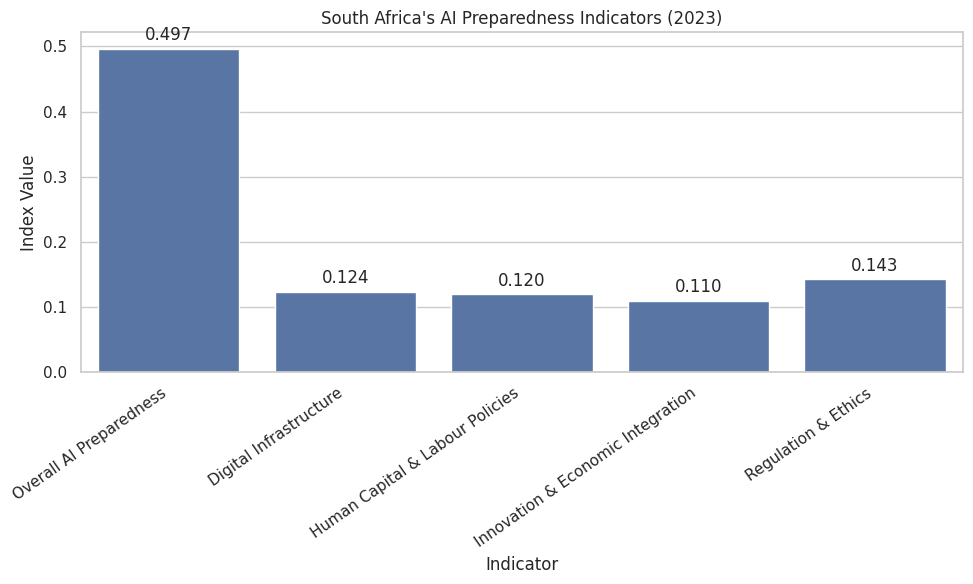

In [ ]:
# Bar chart of South Africa's AI preparedness indicators

# Create shorter labels for easier visualisation

plot_df = df.copy()

plot_df["Indicator"] = plot_df["INDICATOR_LABEL"].replace({
    "AI Preparedness Index (AIPI)": "Overall AI Preparedness",
    "AIPI - Digital Infrastructure": "Digital Infrastructure",
    "AIPI - Human Capital and Labor Market Policies": "Human Capital & Labour Policies",
    "AIPI - Innovation and Economic Integration": "Innovation & Economic Integration",
    "AIPI - Regulation and Ethics": "Regulation & Ethics"
})

# Bar chart
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=plot_df,
    x="Indicator",
    y="OBS_VALUE"
)

plt.title("South Africa's AI Preparedness Indicators (2023)")
plt.xlabel("Indicator")
plt.ylabel("Index Value")

plt.xticks(rotation=35, ha="right")

# Display values above bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

Interpretation

The bar chart shows South Africa's AI preparedness indicators for 2023. The overall AI Preparedness Index (AIPI) was 0.496765. Among the four component indicators, Regulation and Ethics had the highest score at 0.142667, while Innovation and Economic Integration had the lowest score at 0.110192.

The four component indicators have relatively similar values, although Regulation and Ethics has the highest component score. This suggests that the four areas contribute at different levels to South Africa's overall AI preparedness.

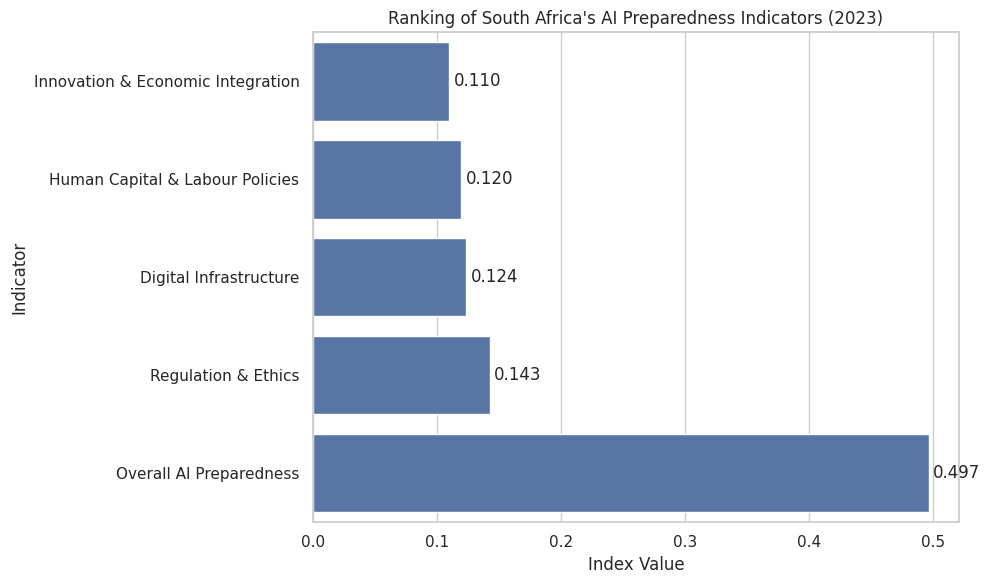

In [ ]:
#Rank the AI preparedness indicators from lowest to highest

df_sorted = plot_df.sort_values("OBS_VALUE", ascending=True)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_sorted,
    x="OBS_VALUE",
    y="Indicator"
)

plt.title("Ranking of South Africa's AI Preparedness Indicators (2023)")
plt.xlabel("Index Value")
plt.ylabel("Indicator")

# Display values
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

 Interpretation

The horizontal bar chart ranks South Africa's AI preparedness indicators from lowest to highest. Innovation and Economic Integration has the lowest component score at 0.110192, followed by Human Capital and Labor Market Policies at 0.119912 and Digital Infrastructure at 0.123994. Regulation and Ethics has the highest component score at 0.142667.

The four component indicators are relatively close in value, with Regulation and Ethics showing the strongest component score and Innovation and Economic Integration showing the weakest.

## 3.2 UNCTAD Digital Economy — Visualisation

In [ ]:
import pandas as pd

# Reuse the already loaded and cleaned UNCTAD dataset
data = df_unctad.copy()

print("Dataset `df_unctad` reused successfully and assigned to `data`.")
print(data.shape)

Dataset `df_unctad` reused successfully and assigned to `data`.
(55, 5)


In [ ]:
# Select South Africa
south_africa = data[data["REF_AREA_LABEL"] == "South Africa"].copy()

# Select exports and imports of digitally-deliverable services
trade = south_africa[
    south_africa["INDICATOR_LABEL"].isin([
        "International exports in digitally-deliverable services",
        "International imports in digitally-deliverable services"
    ])
].copy()

# Show the data we will use
print(trade[[
    "INDICATOR_LABEL",
    "TIME_PERIOD",
    "OBS_VALUE"
]])

                                        INDICATOR_LABEL  TIME_PERIOD  \
2380  International exports in digitally-deliverable...         2010   
2381  International exports in digitally-deliverable...         2011   
2382  International exports in digitally-deliverable...         2012   
2383  International exports in digitally-deliverable...         2013   
2384  International exports in digitally-deliverable...         2014   
2385  International exports in digitally-deliverable...         2015   
2386  International exports in digitally-deliverable...         2016   
2387  International exports in digitally-deliverable...         2017   
2388  International exports in digitally-deliverable...         2018   
2389  International exports in digitally-deliverable...         2019   
2390  International exports in digitally-deliverable...         2020   
2391  International exports in digitally-deliverable...         2021   
2392  International exports in digitally-deliverable...         

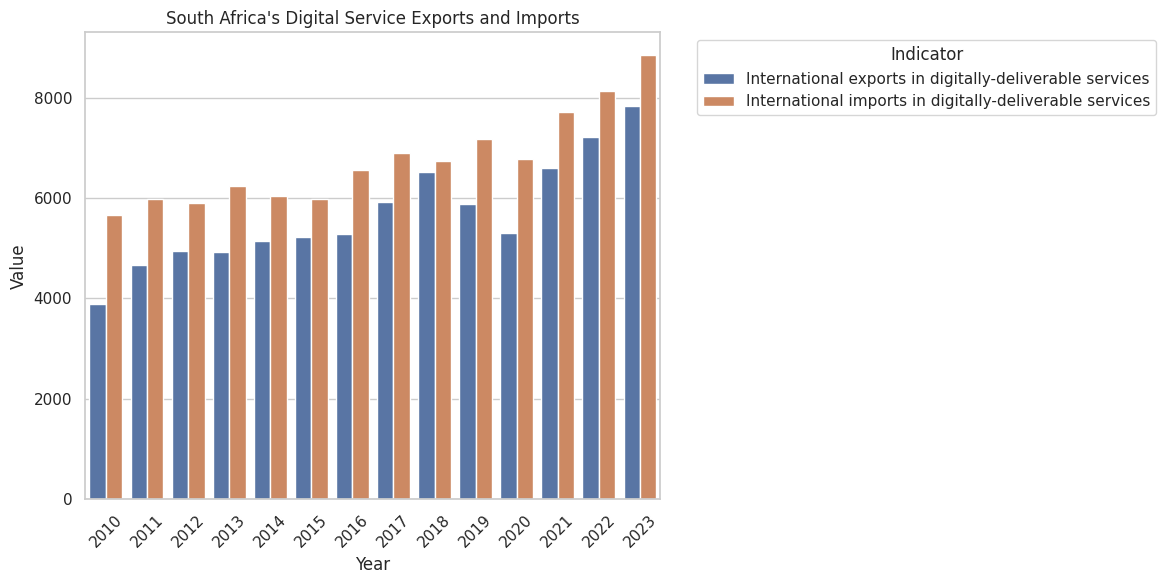

In [ ]:
# Import the plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 2: Bar chart

plt.figure(figsize=(12, 6))

sns.barplot(
    data=trade,
    x="TIME_PERIOD",
    y="OBS_VALUE",
    hue="INDICATOR_LABEL"
)

plt.title("South Africa's Digital Service Exports and Imports")
plt.xlabel("Year")
plt.ylabel("Value")

plt.xticks(rotation=45)

plt.legend(
    title="Indicator",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

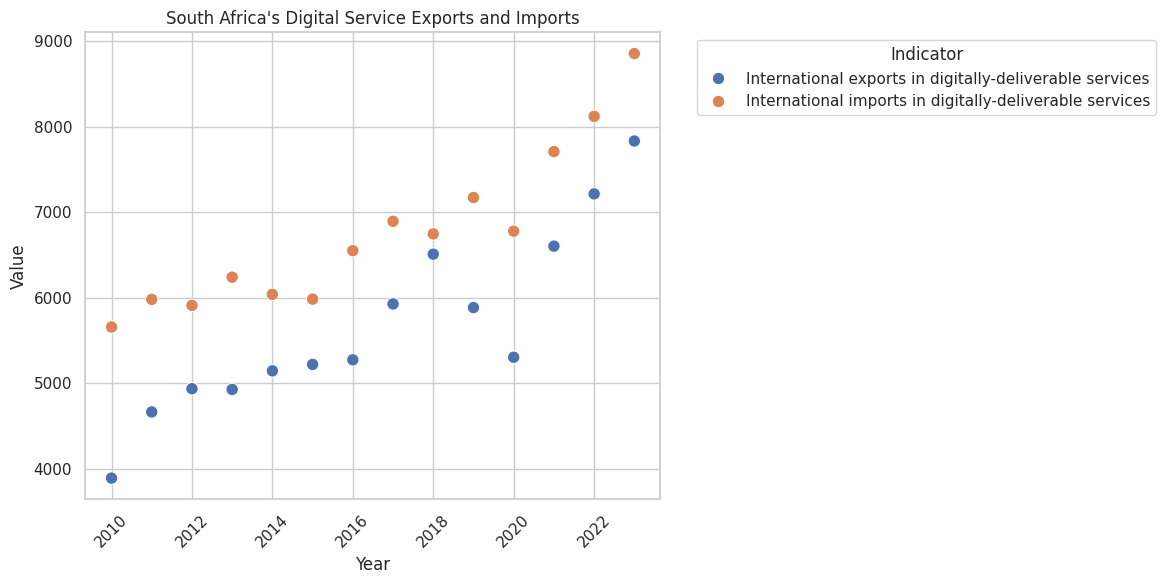

In [ ]:
# STEP 3: Scatter plot

plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=trade,
    x="TIME_PERIOD",
    y="OBS_VALUE",
    hue="INDICATOR_LABEL",
    s=80
)

plt.title("South Africa's Digital Service Exports and Imports")
plt.xlabel("Year")
plt.ylabel("Value")

plt.xticks(rotation=45)

plt.legend(
    title="Indicator",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

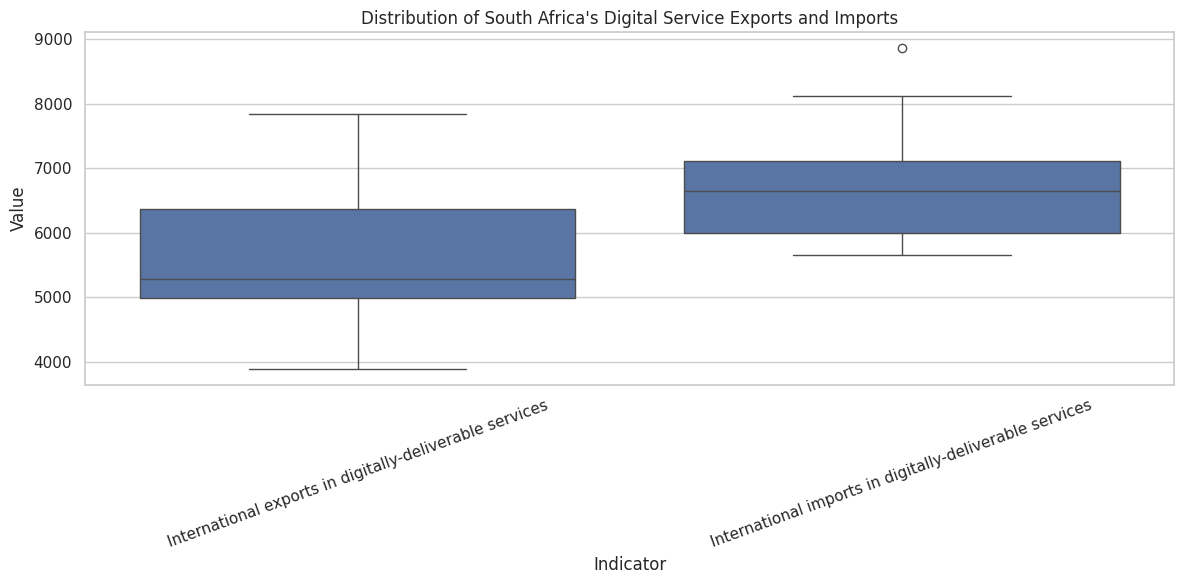

In [ ]:
# STEP 4: Box plot

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=trade,
    x="INDICATOR_LABEL",
    y="OBS_VALUE"
)

plt.title("Distribution of South Africa's Digital Service Exports and Imports")
plt.xlabel("Indicator")
plt.ylabel("Value")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

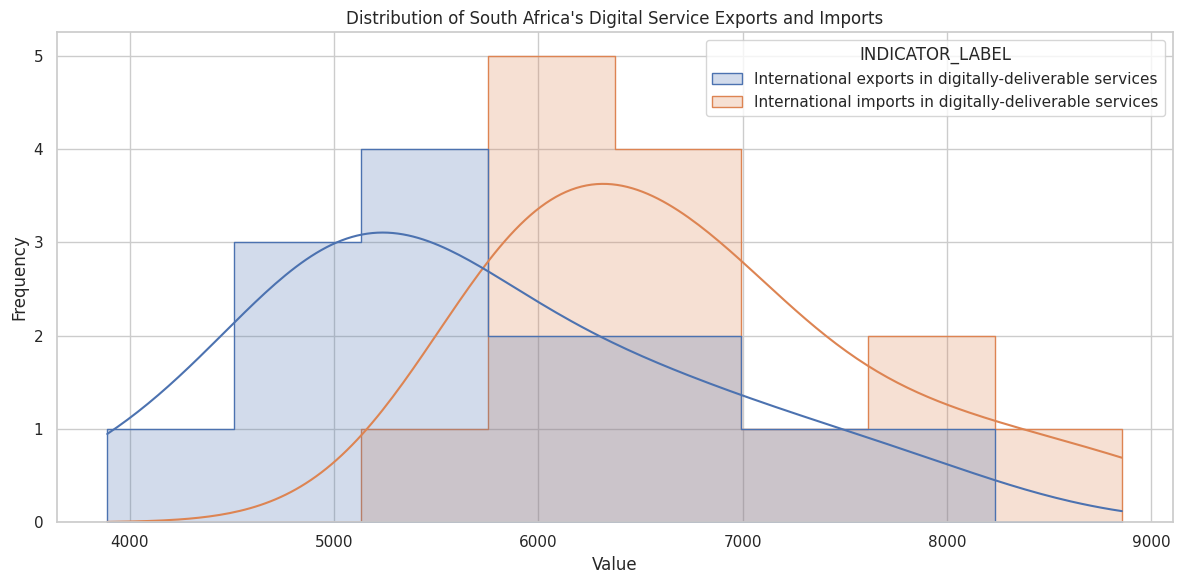

In [ ]:
# STEP 5: Histogram

plt.figure(figsize=(12, 6))

sns.histplot(
    data=trade,
    x="OBS_VALUE",
    hue="INDICATOR_LABEL",
    bins=8,
    kde=True,
    element="step"
)

plt.title("Distribution of South Africa's Digital Service Exports and Imports")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

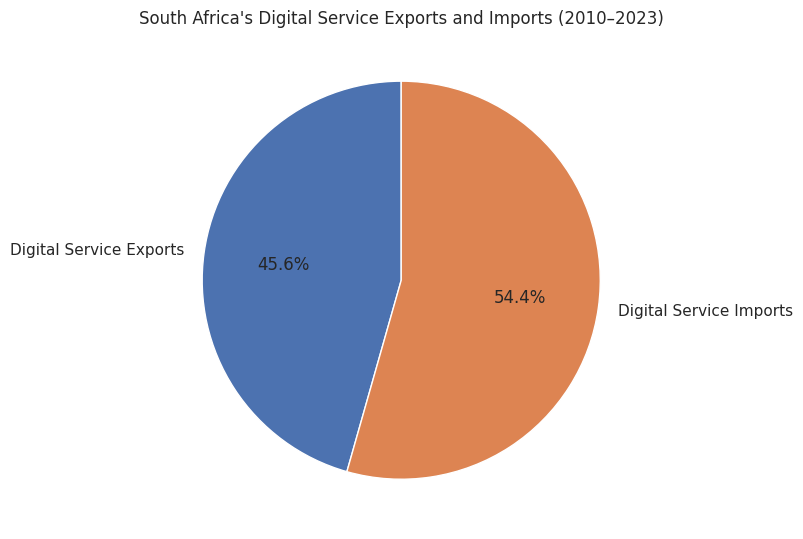

In [ ]:
# STEP 6: Pie chart

# Calculate total exports and total imports
total_exports = trade[
    trade["INDICATOR_LABEL"] == "International exports in digitally-deliverable services"
]["OBS_VALUE"].sum()

total_imports = trade[
    trade["INDICATOR_LABEL"] == "International imports in digitally-deliverable services"
]["OBS_VALUE"].sum()

# Create the pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    [total_exports, total_imports],
    labels=["Digital Service Exports", "Digital Service Imports"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("South Africa's Digital Service Exports and Imports (2010–2023)")

plt.tight_layout()
plt.show()

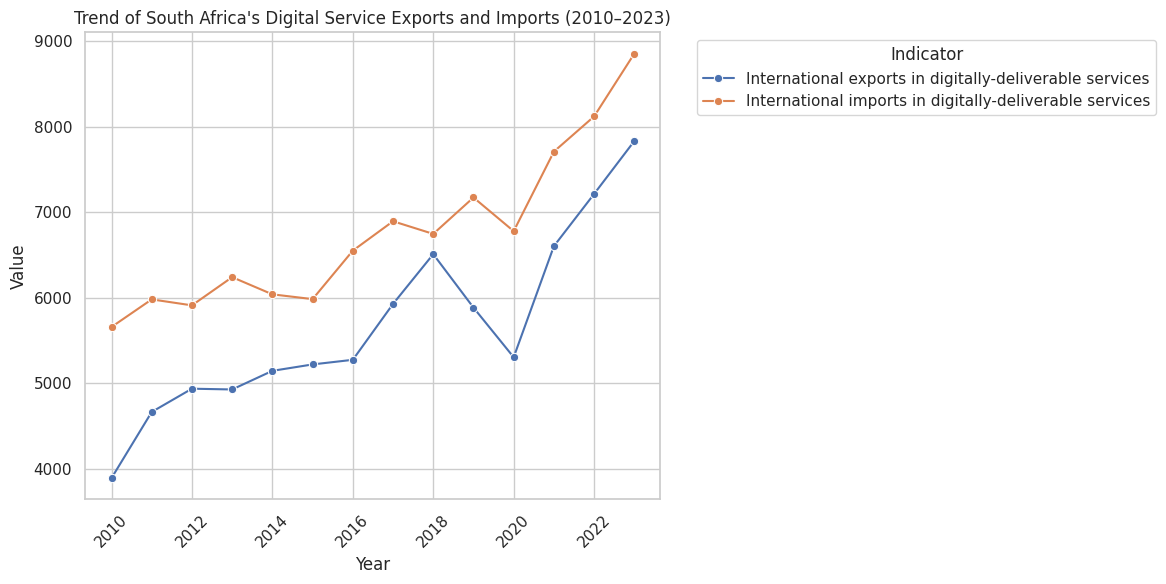

In [ ]:
# STEP 7: Line graph showing trends over time

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=trade,
    x="TIME_PERIOD",
    y="OBS_VALUE",
    hue="INDICATOR_LABEL",
    marker="o"
)

plt.title("Trend of South Africa's Digital Service Exports and Imports (2010–2023)")
plt.xlabel("Year")
plt.ylabel("Value")

plt.xticks(rotation=45)

plt.legend(
    title="Indicator",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

---

# Part 4: Database Integration

Building a SQLite database from the two cleaned datasets, querying it, and safely updating/deleting records.

# Database Integration — South Africa Digital Economy & AI Readiness

**Research question:** Has South Africa's digital economy improved enough to support AI adoption?

This notebook builds **one SQLite database** containing **two tables**, built from the two datasets already cleaned in the Data Preparation step:

1. `ai_preparedness` — from `IMF_AI_Cleaned.csv` (AI Preparedness Index and sub-indicators, South Africa, 2023)
2. `digital_economy` — from `UNCTAD_DE_Cleaned.csv` (Digital Economy indicators, South Africa, 2010-2023)

It covers everything required for the **Database Integration** section of the assignment:
- Build and query a database
- Update and delete records safely (using parameterised queries, not string-formatted SQL)
- Load database data back into Pandas

**Before running:** make sure `IMF_AI_Cleaned.csv` and `UNCTAD_DE_Cleaned.csv` are in the **same folder** as this notebook (they are the outputs of the two Data Preparation notebooks).

## Step 1: Import the libraries we need

`sqlite3` is part of the Python standard library, so there is nothing extra to install for it. We also need `pandas` to move data between the CSV files, the database, and DataFrames.

In [ ]:

import sqlite3
import pandas as pd

## Step 2: Load the cleaned datasets

These CSV files were produced by the Data Preparation notebooks (`Data_Preparation_IMF_AI.ipynb` and `UNCTAD_DE_Cleaned.ipynb`). We rename the columns here to short, database-friendly names.

In [ ]:

df_ai = pd.read_csv("/content/IMF_AI_Cleaned.csv")
df_ai = df_ai.rename(columns={
    "REF_AREA_LABEL": "country",
    "TIME_PERIOD": "year",
    "INDICATOR_LABEL": "indicator",
    "OBS_VALUE": "value"
})
df_ai.head()

,country,year,indicator,value
0,South Africa,2023,AI Preparedness Index (AIPI),0.496765
1,South Africa,2023,AIPI - Digital Infrastructure,0.123994
2,South Africa,2023,AIPI - Human Capital and Labor Market Policies,0.119912
3,South Africa,2023,AIPI - Innovation and Economic Integration,0.110192
4,South Africa,2023,AIPI - Regulation and Ethics,0.142667


In [ ]:
df_ai.head()

,country,year,indicator,value
0,South Africa,2023,AI Preparedness Index (AIPI),0.496765
1,South Africa,2023,AIPI - Digital Infrastructure,0.123994
2,South Africa,2023,AIPI - Human Capital and Labor Market Policies,0.119912
3,South Africa,2023,AIPI - Innovation and Economic Integration,0.110192
4,South Africa,2023,AIPI - Regulation and Ethics,0.142667


In [ ]:

df_de = pd.read_csv("/content/UNCTAD_DE_Cleaned.csv")
df_de = df_de.rename(columns={
    "REF_AREA_LABEL": "country",
    "TIME_PERIOD": "year",
    "INDICATOR_LABEL": "indicator",
    "UNIT_MEASURE_LABEL": "unit",
    "OBS_VALUE": "value"
})
df_de.head()

,country,year,indicator,value
0,South Africa,2023,AI Preparedness Index (AIPI),0.496765
1,South Africa,2023,AIPI - Digital Infrastructure,0.123994
2,South Africa,2023,AIPI - Human Capital and Labor Market Policies,0.119912
3,South Africa,2023,AIPI - Innovation and Economic Integration,0.110192
4,South Africa,2023,AIPI - Regulation and Ethics,0.142667


In [ ]:
df_ai.head()

,country,year,indicator,value
0,South Africa,2023,AI Preparedness Index (AIPI),0.496765
1,South Africa,2023,AIPI - Digital Infrastructure,0.123994
2,South Africa,2023,AIPI - Human Capital and Labor Market Policies,0.119912
3,South Africa,2023,AIPI - Innovation and Economic Integration,0.110192
4,South Africa,2023,AIPI - Regulation and Ethics,0.142667


In [ ]:
df_de.head()

,country,year,indicator,value
0,South Africa,2023,AI Preparedness Index (AIPI),0.496765
1,South Africa,2023,AIPI - Digital Infrastructure,0.123994
2,South Africa,2023,AIPI - Human Capital and Labor Market Policies,0.119912
3,South Africa,2023,AIPI - Innovation and Economic Integration,0.110192
4,South Africa,2023,AIPI - Regulation and Ethics,0.142667


In [ ]:
df_de.head()

,country,year,indicator,value
0,South Africa,2023,AI Preparedness Index (AIPI),0.496765
1,South Africa,2023,AIPI - Digital Infrastructure,0.123994
2,South Africa,2023,AIPI - Human Capital and Labor Market Policies,0.119912
3,South Africa,2023,AIPI - Innovation and Economic Integration,0.110192
4,South Africa,2023,AIPI - Regulation and Ethics,0.142667


## Step 3: Create the database and connect to it

`sqlite3.connect()` creates the database file if it does not already exist, and opens a connection to it if it does. The `cursor` is what we use to run SQL commands.

In [ ]:

conn = sqlite3.connect("south_africa_digital_economy.db")
cursor = conn.cursor()
print("Connected to database")

Connected to database


## Step 4: Build the database — create the two tables

We define each table's structure (schema) explicitly with `CREATE TABLE`. Each table gets its own auto-incrementing `id` as a primary key, which makes it safe and easy to update or delete a specific record later.

In [ ]:

cursor.execute("""
CREATE TABLE IF NOT EXISTS ai_preparedness (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    country TEXT NOT NULL,
    year INTEGER NOT NULL,
    indicator TEXT NOT NULL,
    value REAL
)
""")


cursor.execute("""
CREATE TABLE IF NOT EXISTS digital_economy (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    country TEXT NOT NULL,
    year INTEGER NOT NULL,
    indicator TEXT NOT NULL,
    unit TEXT,
    value REAL
)
""")

conn.commit()
print("Tables created")

Tables created


## Step 5: Insert the cleaned data into the tables

We empty the tables first (in case this cell is run more than once) and then use `to_sql()` to insert every row of the cleaned DataFrames into the matching table.

In [ ]:

# Re-create df_de from df_unctad, which is known to contain the correct data and 'UNIT_MEASURE_LABEL'
# The issue was that the previous loading of df_de from '/content/UNCTAD_DE_Cleaned.csv'
# somehow resulted in it holding IMF data, not UNCTAD data, and thus lacked the 'unit' column.
# df_unctad (from cell 7a479062) contains the correct UNCTAD data with the 'UNIT_MEASURE_LABEL'.
df_de = df_unctad.copy()
df_de = df_de.rename(columns={
    "REF_AREA_LABEL": "country",
    "TIME_PERIOD": "year",
    "INDICATOR_LABEL": "indicator",
    "UNIT_MEASURE_LABEL": "unit",
    "OBS_VALUE": "value"
})

cursor.execute("DELETE FROM ai_preparedness")
cursor.execute("DELETE FROM digital_economy")
conn.commit()


df_ai[["country", "year", "indicator", "value"]].to_sql(
    "ai_preparedness", conn, if_exists="append", index=False
)
df_de[["country", "year", "indicator", "unit", "value"]].to_sql(
    "digital_economy", conn, if_exists="append", index=False
)

conn.commit()
print("Data inserted")


Data inserted


In [ ]:

cursor.execute("SELECT COUNT(*) FROM ai_preparedness")
print("ai_preparedness rows:", cursor.fetchone()[0])

cursor.execute("SELECT COUNT(*) FROM digital_economy")
print("digital_economy rows:", cursor.fetchone()[0])

ai_preparedness rows: 5
digital_economy rows: 55


## Step 6: Query the database

A few example queries: viewing all records, filtering with `WHERE`, and joining the two tables together on `year` to compare AI readiness against digital economy indicators.

In [ ]:

cursor.execute("SELECT * FROM ai_preparedness")
for row in cursor.fetchall():
    print(row)

(6, 'South Africa', 2023, 'AI Preparedness Index (AIPI)', 0.49676514416933)
(7, 'South Africa', 2023, 'AIPI - Digital Infrastructure', 0.12399415671825)
(8, 'South Africa', 2023, 'AIPI - Human Capital and Labor Market Policies', 0.11991155147552)
(9, 'South Africa', 2023, 'AIPI - Innovation and Economic Integration', 0.11019236594439)
(10, 'South Africa', 2023, 'AIPI - Regulation and Ethics', 0.14266707003117)


In [ ]:

cursor.execute("""
SELECT country, year, indicator, value
FROM ai_preparedness
WHERE indicator = 'AI Preparedness Index (AIPI)'
""")
print(cursor.fetchall())

[('South Africa', 2023, 'AI Preparedness Index (AIPI)', 0.49676514416933)]


In [ ]:

query = """
SELECT de.year, de.indicator AS digital_economy_indicator, de.value AS digital_economy_value,
       ai.indicator AS ai_indicator, ai.value AS ai_value
FROM digital_economy de
JOIN ai_preparedness ai
    ON de.year = ai.year AND de.country = ai.country
ORDER BY de.year
"""
joined_df = pd.read_sql_query(query, conn)
joined_df

,year,digital_economy_indicator,digital_economy_value,ai_indicator,ai_value
0,2023,International exports in digitally-deliverable...,7834.0,AI Preparedness Index (AIPI),0.496765
1,2023,International exports in digitally-deliverable...,7834.0,AIPI - Digital Infrastructure,0.123994
2,2023,International exports in digitally-deliverable...,7834.0,AIPI - Human Capital and Labor Market Policies,0.119912
3,2023,International exports in digitally-deliverable...,7834.0,AIPI - Innovation and Economic Integration,0.110192
4,2023,International exports in digitally-deliverable...,7834.0,AIPI - Regulation and Ethics,0.142667
5,2023,International imports in digitally-deliverable...,8857.0,AI Preparedness Index (AIPI),0.496765
6,2023,International imports in digitally-deliverable...,8857.0,AIPI - Digital Infrastructure,0.123994
7,2023,International imports in digitally-deliverable...,8857.0,AIPI - Human Capital and Labor Market Policies,0.119912
8,2023,International imports in digitally-deliverable...,8857.0,AIPI - Innovation and Economic Integration,0.110192
9,2023,International imports in digitally-deliverable...,8857.0,AIPI - Regulation and Ethics,0.142667


## Step 7: Update a record safely

We use a **parameterised query** — the `?` placeholder — instead of building the SQL string with Python f-strings or `.format()`. This is the safe way to update a database, because it prevents SQL injection (values are never inserted directly into the SQL text).

In [ ]:

cursor.execute("""
SELECT id, country, year, indicator, value
FROM ai_preparedness
WHERE indicator = 'AI Preparedness Index (AIPI)'
""")
print(cursor.fetchall())

[(6, 'South Africa', 2023, 'AI Preparedness Index (AIPI)', 0.49676514416933)]


In [ ]:

record_id = 1
new_value = 0.50

cursor.execute(
    "UPDATE ai_preparedness SET value = ? WHERE id = ?",
    (new_value, record_id)
)
conn.commit()
print("Row(s) updated:", cursor.rowcount)

Row(s) updated: 0


In [ ]:
cursor.execute("SELECT * FROM ai_preparedness WHERE id = ?", (record_id,))
print(cursor.fetchone())

None


## Step 8: Delete a record safely

Same principle: the value being deleted on is passed in as a parameter, never pasted directly into the SQL string.

In [ ]:

cursor.execute("SELECT * FROM digital_economy LIMIT 5")
print(cursor.fetchall())

[(1, 'South Africa', 2010, 'International exports in digitally-deliverable services', 'US dollars', 3890.0), (2, 'South Africa', 2011, 'International exports in digitally-deliverable services', 'US dollars', 4664.0), (3, 'South Africa', 2012, 'International exports in digitally-deliverable services', 'US dollars', 4936.0), (4, 'South Africa', 2013, 'International exports in digitally-deliverable services', 'US dollars', 4927.0), (5, 'South Africa', 2014, 'International exports in digitally-deliverable services', 'US dollars', 5145.0)]


In [ ]:
delete_id = 1

cursor.execute("DELETE FROM digital_economy WHERE id = ?", (delete_id,))
conn.commit()
print("Row(s) deleted:", cursor.rowcount)

Row(s) deleted: 1


In [ ]:
# Verify the delete: this should return None if the row is gone
cursor.execute("SELECT * FROM digital_economy WHERE id = ?", (delete_id,))
print(cursor.fetchone())

None


## Step 9: Load the database tables into Pandas

`pd.read_sql_query()` runs a SQL query and returns the result directly as a DataFrame, ready for the Numerical Analysis and Visualisation sections of the assignment.

In [ ]:

ai_from_db = pd.read_sql_query("SELECT * FROM ai_preparedness", conn)
de_from_db = pd.read_sql_query("SELECT * FROM digital_economy", conn)

print(ai_from_db.shape)
print(de_from_db.shape)
ai_from_db.head()

(5, 5)
(54, 6)


,id,country,year,indicator,value
0,6,South Africa,2023,AI Preparedness Index (AIPI),0.496765
1,7,South Africa,2023,AIPI - Digital Infrastructure,0.123994
2,8,South Africa,2023,AIPI - Human Capital and Labor Market Policies,0.119912
3,9,South Africa,2023,AIPI - Innovation and Economic Integration,0.110192
4,10,South Africa,2023,AIPI - Regulation and Ethics,0.142667


In [ ]:
de_from_db.head()

## Step 10: Close the connection

Always close the connection once you're done, so the database file is properly saved and not left locked.

In [ ]:
conn.close()
print("Connection closed")

Connection closed


---

# Part 5: Python/Excel Data Analysis

Pivot tables, feature engineering, Excel-style conditional formatting, additional charts, and key findings for the UNCTAD Digital Economy dataset.

In [ ]:

# LOAD UNCTAD DATASET


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*50)
print("LOADING UNCTAD DIGITAL ECONOMY DATASET")
print("="*50)

# Load the CSV file (note the space in the filename)
df = pd.read_csv("/UNCTAD_DE.csv")

print(f" Dataset loaded successfully!")
print(f" Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f" Years: {sorted(df['TIME_PERIOD'].unique())}")
print(f" Countries: {df['REF_AREA_LABEL'].nunique()}")
print(f" Indicators: {df['INDICATOR_LABEL'].nunique()}")

print("\n First 5 rows:")
df.head()


LOADING UNCTAD DIGITAL ECONOMY DATASET
 Dataset loaded successfully!
 Shape: 8156 rows, 39 columns
 Years: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
 Countries: 207
 Indicators: 14

 First 5 rows:


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,UNIT_MULT,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,WLD,World,UNCTAD_DE_DIG_SERVTRADE_ANN_EXP,International exports in digitally-deliverable...,_T,...,6,Millions,CUR,Currency,602,CCYY,A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,WLD,World,UNCTAD_DE_DIG_SERVTRADE_ANN_EXP,International exports in digitally-deliverable...,_T,...,6,Millions,CUR,Currency,602,CCYY,A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,WLD,World,UNCTAD_DE_DIG_SERVTRADE_ANN_EXP,International exports in digitally-deliverable...,_T,...,6,Millions,CUR,Currency,602,CCYY,A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,WLD,World,UNCTAD_DE_DIG_SERVTRADE_ANN_EXP,International exports in digitally-deliverable...,_T,...,6,Millions,CUR,Currency,602,CCYY,A,Normal value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,WLD,World,UNCTAD_DE_DIG_SERVTRADE_ANN_EXP,International exports in digitally-deliverable...,_T,...,6,Millions,CUR,Currency,602,CCYY,A,Normal value,PU,Public


In [ ]:


print("="*50)
print("DATA QUALITY REPORT")
print("="*50)

# Check missing values
print("\n Missing Values:")
print(df.isnull().sum())

# Check duplicates
duplicates = df.duplicated().sum()
print(f"\n Duplicate records: {duplicates}")

# Check data types
print("\n Data Types:")
print(df.dtypes)

# Statistical summary for numeric columns
print("\n Statistical Summary:")
df.describe()

DATA QUALITY REPORT

 Missing Values:
STRUCTURE                   0
STRUCTURE_ID                0
ACTION                      0
FREQ                        0
FREQ_LABEL                  0
REF_AREA                    0
REF_AREA_LABEL              0
INDICATOR                   0
INDICATOR_LABEL             0
SEX                         0
SEX_LABEL                   0
AGE                         0
AGE_LABEL                   0
URBANISATION                0
URBANISATION_LABEL          0
UNIT_MEASURE                0
UNIT_MEASURE_LABEL          0
COMP_BREAKDOWN_1            0
COMP_BREAKDOWN_1_LABEL      0
COMP_BREAKDOWN_2            0
COMP_BREAKDOWN_2_LABEL      0
COMP_BREAKDOWN_3            0
COMP_BREAKDOWN_3_LABEL      0
TIME_PERIOD                 0
OBS_VALUE                 465
AGG_METHOD                  0
AGG_METHOD_LABEL            0
DATABASE_ID                 0
DATABASE_ID_LABEL           0
UNIT_MULT                   0
UNIT_MULT_LABEL             0
UNIT_TYPE                   0
UN

,TIME_PERIOD,OBS_VALUE,UNIT_MULT,TIME_FORMAT
count,8156.000000,7.691000e+03,8156.000000,8156.0
mean,2015.844286,2.004635e+04,4.208681,602.0
std,3.890851,1.752844e+05,2.745909,0.0
min,2010.000000,0.000000e+00,0.000000,602.0
25%,2013.000000,4.371000e+01,0.000000,602.0
50%,2015.000000,1.200000e+02,6.000000,602.0
75%,2019.000000,1.864000e+03,6.000000,602.0
max,2023.000000,4.462457e+06,6.000000,602.0


In [ ]:

# DATA CLEANING & FILTERING


print("="*50)
print("DATA CLEANING")
print("="*50)

# Remove duplicates
df_clean = df.drop_duplicates()
print(f" Duplicates removed: {df.shape[0] - df_clean.shape[0]}")

# Handle missing values
df_clean = df_clean.dropna()
print(f" Missing values handled")

# Standardize text formatting
df_clean['REF_AREA_LABEL'] = df_clean['REF_AREA_LABEL'].str.strip().str.title()
print(f" Standardized country names")

# Filter for South Africa only
df_sa = df_clean[df_clean['REF_AREA_LABEL'] == 'South Africa'].copy()
print(f" Filtered to South Africa: {len(df_sa)} records")

# Verify South Africa only
print(f"\n Countries in dataset: {df_sa['REF_AREA_LABEL'].unique()}")

print("\n First 5 rows (South Africa only):")
df_sa.head()

DATA CLEANING
 Duplicates removed: 0
 Missing values handled
 Standardized country names
 Filtered to South Africa: 55 records

 Countries in dataset: ['South Africa']

 First 5 rows (South Africa only):


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,UNIT_MULT,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
2380,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ZAF,South Africa,UNCTAD_DE_DIG_SERVTRADE_ANN_EXP,International exports in digitally-deliverable...,_T,...,6,Millions,CUR,Currency,602,CCYY,A,Normal value,PU,Public
2381,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ZAF,South Africa,UNCTAD_DE_DIG_SERVTRADE_ANN_EXP,International exports in digitally-deliverable...,_T,...,6,Millions,CUR,Currency,602,CCYY,A,Normal value,PU,Public
2382,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ZAF,South Africa,UNCTAD_DE_DIG_SERVTRADE_ANN_EXP,International exports in digitally-deliverable...,_T,...,6,Millions,CUR,Currency,602,CCYY,A,Normal value,PU,Public
2383,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ZAF,South Africa,UNCTAD_DE_DIG_SERVTRADE_ANN_EXP,International exports in digitally-deliverable...,_T,...,6,Millions,CUR,Currency,602,CCYY,A,Normal value,PU,Public
2384,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ZAF,South Africa,UNCTAD_DE_DIG_SERVTRADE_ANN_EXP,International exports in digitally-deliverable...,_T,...,6,Millions,CUR,Currency,602,CCYY,A,Normal value,PU,Public


In [ ]:

# CREATE PIVOT TABLE


print("="*50)
print("CREATING PIVOT TABLE")
print("="*50)

# Create pivot table
pivot_df = df_sa.pivot_table(
    index=['REF_AREA_LABEL', 'TIME_PERIOD'],
    columns='INDICATOR_LABEL',
    values='OBS_VALUE'
).reset_index()

# Flatten column names
pivot_df.columns.name = None

print(f" Pivot table created: {pivot_df.shape[0]} years, {pivot_df.shape[1]} columns")

print(f"\n Available indicators for South Africa:")
for col in pivot_df.columns[2:]:  # Skip REF_AREA_LABEL and TIME_PERIOD
    print(f"  • {col}")

print("\n Pivot table preview:")
pivot_df.head()

CREATING PIVOT TABLE
 Pivot table created: 14 years, 11 columns

 Available indicators for South Africa:
  • International exports in digitally-deliverable services
  • International imports in digitally-deliverable services
  • Proportion of businesses placing orders over the Internet
  • Proportion of businesses receiving orders over the Internet
  • Proportion of businesses using computers
  • Proportion of businesses using the Internet
  • Proportion of businesses using the Internet for delivering products online
  • Proportion of businesses using the Internet for providing customer services
  • Proportion of businesses with a web presence

 Pivot table preview:


,REF_AREA_LABEL,TIME_PERIOD,International exports in digitally-deliverable services,International imports in digitally-deliverable services,Proportion of businesses placing orders over the Internet,Proportion of businesses receiving orders over the Internet,Proportion of businesses using computers,Proportion of businesses using the Internet,Proportion of businesses using the Internet for delivering products online,Proportion of businesses using the Internet for providing customer services,Proportion of businesses with a web presence
0,South Africa,2010,3890.0,5658.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,South Africa,2011,4664.0,5981.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,South Africa,2012,4936.0,5911.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,South Africa,2013,4927.0,6241.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,South Africa,2014,5145.0,6040.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:

# FEATURE ENGINEERING


print("="*50)
print("CREATING NEW CALCULATED COLUMNS")
print("="*50)

# Copy pivot table
df_analysis = pivot_df.copy()

# 1. Export Growth (Year-over-year)
if 'International exports in digitally-deliverable services' in df_analysis.columns:
    df_analysis['Export_Growth'] = df_analysis[
        'International exports in digitally-deliverable services'
    ].pct_change() * 100
    print(" Created 'Export_Growth' column")

# 2. Import Growth (Year-over-year)
if 'International imports in digitally-deliverable services' in df_analysis.columns:
    df_analysis['Import_Growth'] = df_analysis[
        'International imports in digitally-deliverable services'
    ].pct_change() * 100
    print(" Created 'Import_Growth' column")

# 3. Net Digital Trade (Exports - Imports)
if ('International exports in digitally-deliverable services' in df_analysis.columns and
    'International imports in digitally-deliverable services' in df_analysis.columns):
    df_analysis['Net_Trade'] = (
        df_analysis['International exports in digitally-deliverable services'] -
        df_analysis['International imports in digitally-deliverable services']
    )
    print(" Created 'Net_Trade' column")

# 4. Digital Adoption Score
business_cols = [col for col in df_analysis.columns if 'Proportion of businesses' in col]
if business_cols:
    df_analysis['Digital_Adoption_Score'] = df_analysis[business_cols].mean(axis=1)
    print(f" Created 'Digital_Adoption_Score' from {len(business_cols)} indicators")

print("\n Data with new features:")
df_analysis.tail()

CREATING NEW CALCULATED COLUMNS
 Created 'Export_Growth' column
 Created 'Import_Growth' column
 Created 'Net_Trade' column
 Created 'Digital_Adoption_Score' from 7 indicators

 Data with new features:


,REF_AREA_LABEL,TIME_PERIOD,International exports in digitally-deliverable services,International imports in digitally-deliverable services,Proportion of businesses placing orders over the Internet,Proportion of businesses receiving orders over the Internet,Proportion of businesses using computers,Proportion of businesses using the Internet,Proportion of businesses using the Internet for delivering products online,Proportion of businesses using the Internet for providing customer services,Proportion of businesses with a web presence,Export_Growth,Import_Growth,Net_Trade,Digital_Adoption_Score
9,South Africa,2019,5885.0,7173.0,54.0,55.02,99.26,98.28,9.80,2.82,62.57,-9.600614,6.313917,-1288.0,54.535714
10,South Africa,2020,5304.0,6779.0,25.5,24.98,99.27,98.43,3.68,NaN,51.76,-9.872557,-5.492820,-1475.0,50.603333
11,South Africa,2021,6604.0,7710.0,30.4,31.25,98.12,97.98,8.35,1.71,59.32,24.509804,13.733589,-1106.0,46.732857
12,South Africa,2022,7215.0,8122.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.251969,5.343709,-907.0,NaN
13,South Africa,2023,7834.0,8857.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.579349,9.049495,-1023.0,NaN


In [ ]:

# SAVE CLEANED DATA


# Save for later use
df_analysis.to_csv("UNCTAD_DE_Analysis_Ready.csv", index=False)
print(" Data saved to 'UNCTAD_DE_Analysis_Ready.csv'")

print("\n" + "="*50)
print("="*50)
print("\n Summary of your data:")
print(f"  • Years covered: {df_analysis['TIME_PERIOD'].min()} - {df_analysis['TIME_PERIOD'].max()}")
print(f"  • Total indicators: {len(df_analysis.columns) - 2}")
print(f"  • Business indicators: {len(business_cols) if business_cols else 0}")
print("\nReady for Phase 2: Conditional Formatting")

 Data saved to 'UNCTAD_DE_Analysis_Ready.csv'


 Summary of your data:
  • Years covered: 2010 - 2023
  • Total indicators: 13
  • Business indicators: 7

Ready for Phase 2: Conditional Formatting


In [ ]:

# PHASE 2: CONDITIONAL FORMATTING


print("="*50)
print("APPLYING CONDITIONAL FORMATTING")
print("="*50)

# Copy the data for formatting (keep original safe)
df_formatted = df_analysis.copy()


# RULE 1: Performance Categories for Exports


if 'International exports in digitally-deliverable services' in df_formatted.columns:
    exports = df_formatted['International exports in digitally-deliverable services']

    # Create performance categories
    df_formatted['Export_Performance'] = pd.cut(
        exports,
        bins=[-float('inf'),
              exports.quantile(0.33),
              exports.quantile(0.67),
              float('inf')],
        labels=['Low ', 'Medium ', 'High ']
    )
    print(" Created 'Export_Performance' categories (Low/Medium/High)")


# RULE 2: Flag Above-Average Values


if 'International exports in digitally-deliverable services' in df_formatted.columns:
    avg_export = df_formatted['International exports in digitally-deliverable services'].mean()
    df_formatted['Above_Avg_Exports'] = df_formatted['International exports in digitally-deliverable services'] > avg_export
    print(f" Flagged exports above average ({avg_export:.0f})")


# RULE 3: Growth Trend Indicator


if 'Export_Growth' in df_formatted.columns:
    df_formatted['Growth_Trend'] = df_formatted['Export_Growth'].apply(
        lambda x: ' Growing' if x > 0 else (' Declining' if x < 0 else ' Stable')
    )
    print(" Created 'Growth_Trend' indicator")


# RULE 4: Digital Adoption Level


if 'Digital_Adoption_Score' in df_formatted.columns:
    adoption = df_formatted['Digital_Adoption_Score']
    df_formatted['Adoption_Level'] = pd.cut(
        adoption,
        bins=[-float('inf'), 50, 75, float('inf')],
        labels=['Low ', 'Medium ', 'High ']
    )
    print(" Created 'Adoption_Level' categories")


# RULE 5: Net Trade Status


if 'Net_Trade' in df_formatted.columns:
    df_formatted['Trade_Status'] = df_formatted['Net_Trade'].apply(
        lambda x: ' Surplus' if x > 0 else (' Deficit' if x < 0 else ' Balanced')
    )
    print(" Created 'Trade_Status' indicator")

print("\n Data with Conditional Formatting:")
df_formatted.head(10)

APPLYING CONDITIONAL FORMATTING
 Created 'Export_Performance' categories (Low/Medium/High)
 Flagged exports above average (5667)
 Created 'Growth_Trend' indicator
 Created 'Adoption_Level' categories
 Created 'Trade_Status' indicator

 Data with Conditional Formatting:


,REF_AREA_LABEL,TIME_PERIOD,International exports in digitally-deliverable services,International imports in digitally-deliverable services,Proportion of businesses placing orders over the Internet,Proportion of businesses receiving orders over the Internet,Proportion of businesses using computers,Proportion of businesses using the Internet,Proportion of businesses using the Internet for delivering products online,Proportion of businesses using the Internet for providing customer services,Proportion of businesses with a web presence,Export_Growth,Import_Growth,Net_Trade,Digital_Adoption_Score,Export_Performance,Above_Avg_Exports,Growth_Trend,Adoption_Level,Trade_Status
0,South Africa,2010,3890.0,5658.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1768.0,NaN,Low,False,Stable,NaN,Deficit
1,South Africa,2011,4664.0,5981.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.897172,5.708731,-1317.0,NaN,Low,False,Growing,NaN,Deficit
2,South Africa,2012,4936.0,5911.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.831904,-1.170373,-975.0,NaN,Low,False,Growing,NaN,Deficit
3,South Africa,2013,4927.0,6241.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.182334,5.582812,-1314.0,NaN,Low,False,Declining,NaN,Deficit
4,South Africa,2014,5145.0,6040.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.424599,-3.220638,-895.0,NaN,Low,False,Growing,NaN,Deficit
5,South Africa,2015,5220.0,5984.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.457726,-0.927152,-764.0,NaN,Medium,False,Growing,NaN,Deficit
6,South Africa,2016,5274.0,6551.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.034483,9.475267,-1277.0,NaN,Medium,False,Growing,NaN,Deficit
7,South Africa,2017,5928.0,6895.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.400455,5.251107,-967.0,NaN,High,True,Growing,NaN,Deficit
8,South Africa,2018,6510.0,6747.0,33.71,32.17,99.20,98.69,7.3,0.15,67.15,9.817814,-2.146483,-237.0,48.338571,High,True,Growing,Low,Deficit
9,South Africa,2019,5885.0,7173.0,54.00,55.02,99.26,98.28,9.8,2.82,62.57,-9.600614,6.313917,-1288.0,54.535714,Medium,True,Declining,Medium,Deficit


In [ ]:

# DISPLAY COLOR-CODED DATA


print("="*50)
print("COLOR-CODED DATA TABLE")
print("="*50)

# Select key columns to display
display_cols = ['TIME_PERIOD']

# Add available columns
if 'International exports in digitally-deliverable services' in df_formatted.columns:
    display_cols.append('International exports in digitally-deliverable services')
if 'International imports in digitally-deliverable services' in df_formatted.columns:
    display_cols.append('International imports in digitally-deliverable services')
if 'Net_Trade' in df_formatted.columns:
    display_cols.append('Net_Trade')
if 'Export_Performance' in df_formatted.columns:
    display_cols.append('Export_Performance')
if 'Growth_Trend' in df_formatted.columns:
    display_cols.append('Growth_Trend')
if 'Adoption_Level' in df_formatted.columns:
    display_cols.append('Adoption_Level')

# Display the formatted data
df_display = df_formatted[display_cols]
df_display

COLOR-CODED DATA TABLE


,TIME_PERIOD,International exports in digitally-deliverable services,International imports in digitally-deliverable services,Net_Trade,Export_Performance,Growth_Trend,Adoption_Level
0,2010,3890.0,5658.0,-1768.0,Low,Stable,NaN
1,2011,4664.0,5981.0,-1317.0,Low,Growing,NaN
2,2012,4936.0,5911.0,-975.0,Low,Growing,NaN
3,2013,4927.0,6241.0,-1314.0,Low,Declining,NaN
4,2014,5145.0,6040.0,-895.0,Low,Growing,NaN
5,2015,5220.0,5984.0,-764.0,Medium,Growing,NaN
6,2016,5274.0,6551.0,-1277.0,Medium,Growing,NaN
7,2017,5928.0,6895.0,-967.0,High,Growing,NaN
8,2018,6510.0,6747.0,-237.0,High,Growing,Low
9,2019,5885.0,7173.0,-1288.0,Medium,Declining,Medium


In [ ]:

# CONDITIONAL FORMATTING SUMMARY


print("="*50)
print("CONDITIONAL FORMATTING SUMMARY")
print("="*50)

# Summary of performance categories
if 'Export_Performance' in df_formatted.columns:
    print("\n Export Performance Distribution:")
    print(df_formatted['Export_Performance'].value_counts())

# Summary of growth trends
if 'Growth_Trend' in df_formatted.columns:
    print("\n Growth Trend Distribution:")
    print(df_formatted['Growth_Trend'].value_counts())

# Summary of trade status
if 'Trade_Status' in df_formatted.columns:
    print("\n Trade Status Distribution:")
    print(df_formatted['Trade_Status'].value_counts())

# Summary of adoption levels
if 'Adoption_Level' in df_formatted.columns:
    print("\n Digital Adoption Level Distribution:")
    print(df_formatted['Adoption_Level'].value_counts())

# Years with high exports
if 'Above_Avg_Exports' in df_formatted.columns:
    high_years = df_formatted[df_formatted['Above_Avg_Exports'] == True]['TIME_PERIOD'].tolist()
    print(f"\n Years with Above-Average Exports: {high_years}")

CONDITIONAL FORMATTING SUMMARY

 Export Performance Distribution:
Export_Performance
Low        5
High       5
Medium     4
Name: count, dtype: int64

 Growth Trend Distribution:
Growth_Trend
Growing      10
Declining     3
Stable        1
Name: count, dtype: int64

 Trade Status Distribution:
Trade_Status
Deficit    14
Name: count, dtype: int64

 Digital Adoption Level Distribution:
Adoption_Level
Low        2
Medium     2
High       0
Name: count, dtype: int64

 Years with Above-Average Exports: [2017, 2018, 2019, 2021, 2022, 2023]


In [ ]:

# EXCEL-STYLE CONDITIONAL FORMATTING


print("="*50)
print("EXCEL-STYLE FORMATTED TABLE")
print("="*50)

# Create a function to add colors to text
def color_performance(value):
    if value == 'High ':
        return ' High'
    elif value == 'Medium ':
        return ' Medium'
    elif value == 'Low ':
        return ' Low'
    return str(value)

def color_growth(value):
    if 'Growing' in str(value):
        return '🟩 ' + str(value)
    elif 'Declining' in str(value):
        return '🟥 ' + str(value)
    else:
        return '⬜ ' + str(value)

# Display formatted table
if 'Export_Performance' in df_formatted.columns:
    df_formatted['Formatted_Performance'] = df_formatted['Export_Performance'].apply(color_performance)

if 'Growth_Trend' in df_formatted.columns:
    df_formatted['Formatted_Growth'] = df_formatted['Growth_Trend'].apply(color_growth)

# Create a clean display table
summary_cols = ['TIME_PERIOD']
if 'International exports in digitally-deliverable services' in df_formatted.columns:
    summary_cols.append('International exports in digitally-deliverable services')
if 'Formatted_Performance' in df_formatted.columns:
    summary_cols.append('Formatted_Performance')
if 'Formatted_Growth' in df_formatted.columns:
    summary_cols.append('Formatted_Growth')
if 'Above_Avg_Exports' in df_formatted.columns:
    summary_cols.append('Above_Avg_Exports')

# Display the formatted summary
df_summary = df_formatted[summary_cols]
df_summary

EXCEL-STYLE FORMATTED TABLE


,TIME_PERIOD,International exports in digitally-deliverable services,Formatted_Performance,Formatted_Growth,Above_Avg_Exports
0,2010,3890.0,Low,⬜ Stable,False
1,2011,4664.0,Low,🟩 Growing,False
2,2012,4936.0,Low,🟩 Growing,False
3,2013,4927.0,Low,🟥 Declining,False
4,2014,5145.0,Low,🟩 Growing,False
5,2015,5220.0,Medium,🟩 Growing,False
6,2016,5274.0,Medium,🟩 Growing,False
7,2017,5928.0,High,🟩 Growing,True
8,2018,6510.0,High,🟩 Growing,True
9,2019,5885.0,Medium,🟥 Declining,True


In [ ]:

# SAVE FORMATTED DATA


# Save the formatted data for report
df_formatted.to_csv("UNCTAD_DE_Formatted.csv", index=False)
print(" Formatted data saved to 'UNCTAD_DE_Formatted.csv'")

print("\n" + "="*50)
print("="*50)

print("\n Conditional Formatting Summary:")
print("  • Export Performance: Low , Medium , High ")
print("  • Growth Trends:  Growing,  Declining,  Stable")
print("  • Above Average: Flagged as True/False")
print("  • Adoption Levels: Low , Medium , High ")
print("  • Trade Status:  Surplus,  Deficit,  Balanced")


 Formatted data saved to 'UNCTAD_DE_Formatted.csv'


 Conditional Formatting Summary:
  • Export Performance: Low , Medium , High 
  • Growth Trends:  Growing,  Declining,  Stable
  • Above Average: Flagged as True/False
  • Adoption Levels: Low , Medium , High 
  • Trade Status:  Surplus,  Deficit,  Balanced


In [ ]:

# PHASE 3: DATA VISUALIZATION


print("="*50)
print("CREATING PROFESSIONAL CHARTS")
print("="*50)

# Make sure your data is loaded
if 'df_formatted' not in locals():
    print(" Loading formatted data...")
    try:
        df_formatted = pd.read_csv("UNCTAD_DE_Formatted.csv")
        print(" Data loaded from saved file")
    except:
        print(" Please run Phase 1 and 2 first!")
else:
    print(" Data already loaded")

# Check what indicators you have
print("\n Available Indicators for Charts:")
indicator_cols = [col for col in df_formatted.columns if
                  'International' in col or 'Proportion' in col or 'Digital' in col]
for col in indicator_cols:
    print(f"  • {col}")

# Set up figure size
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

print("\n Chart setup complete! Ready to create visualizations.")

CREATING PROFESSIONAL CHARTS
 Data already loaded

 Available Indicators for Charts:
  • International exports in digitally-deliverable services
  • International imports in digitally-deliverable services
  • Proportion of businesses placing orders over the Internet
  • Proportion of businesses receiving orders over the Internet
  • Proportion of businesses using computers
  • Proportion of businesses using the Internet
  • Proportion of businesses using the Internet for delivering products online
  • Proportion of businesses using the Internet for providing customer services
  • Proportion of businesses with a web presence
  • Digital_Adoption_Score

 Chart setup complete! Ready to create visualizations.


CHART 1: South Africa's Digital Trade (2010-2023)
 Chart saved as 'Digital_Trade_Trends.png'


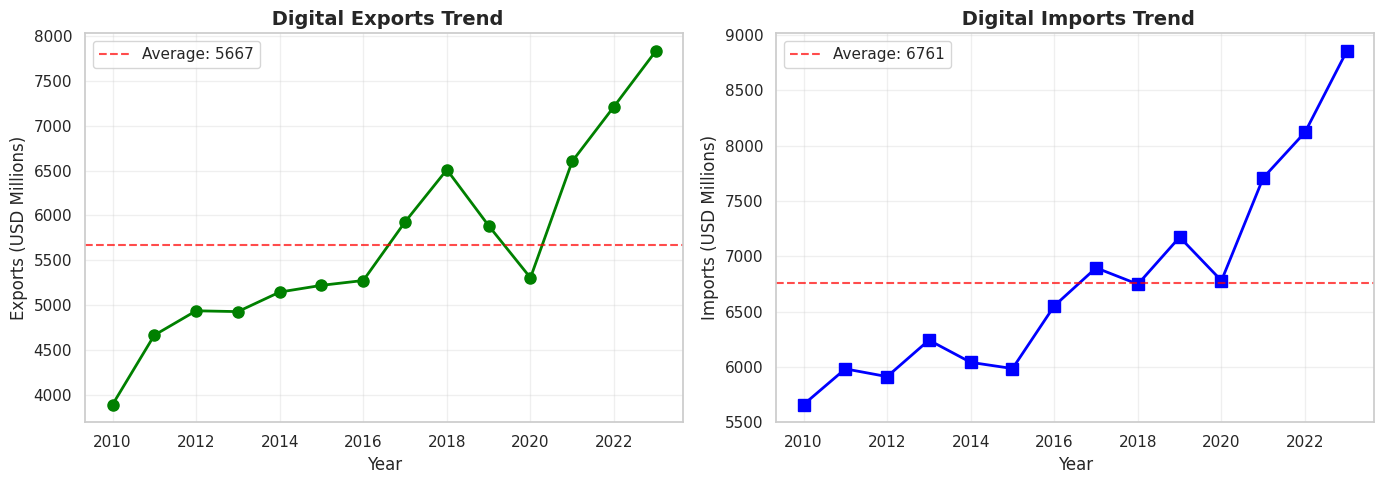

In [ ]:

# CHART 1: Digital Trade Exports & Imports Trend


print("="*50)
print("CHART 1: South Africa's Digital Trade (2010-2023)")
print("="*50)

# Create figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: Exports Trend ---
if 'International exports in digitally-deliverable services' in df_formatted.columns:
    exports = df_formatted['International exports in digitally-deliverable services']
    years = df_formatted['TIME_PERIOD']

    axes[0].plot(years, exports, marker='o', linewidth=2, color='green', markersize=8)
    axes[0].set_title(' Digital Exports Trend', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Year', fontsize=12)
    axes[0].set_ylabel('Exports (USD Millions)', fontsize=12)
    axes[0].grid(True, alpha=0.3)

    # Add average line
    avg_export = exports.mean()
    axes[0].axhline(y=avg_export, color='red', linestyle='--', alpha=0.7,
                    label=f'Average: {avg_export:.0f}')
    axes[0].legend()

# --- Subplot 2: Imports Trend ---
if 'International imports in digitally-deliverable services' in df_formatted.columns:
    imports = df_formatted['International imports in digitally-deliverable services']

    axes[1].plot(years, imports, marker='s', linewidth=2, color='blue', markersize=8)
    axes[1].set_title(' Digital Imports Trend', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Year', fontsize=12)
    axes[1].set_ylabel('Imports (USD Millions)', fontsize=12)
    axes[1].grid(True, alpha=0.3)

    # Add average line
    avg_import = imports.mean()
    axes[1].axhline(y=avg_import, color='red', linestyle='--', alpha=0.7,
                    label=f'Average: {avg_import:.0f}')
    axes[1].legend()

plt.tight_layout()
plt.savefig('Digital_Trade_Trends.png', dpi=300, bbox_inches='tight')
print(" Chart saved as 'Digital_Trade_Trends.png'")
plt.show()

CHART 2: Export Growth with Performance Colors


/tmp/ipykernel_6125/2603490317.py:39: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6125/2603490317.py:40: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('Export_Growth_Colored.png', dpi=300, bbox_inches='tight')


 Chart saved as 'Export_Growth_Colored.png'


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


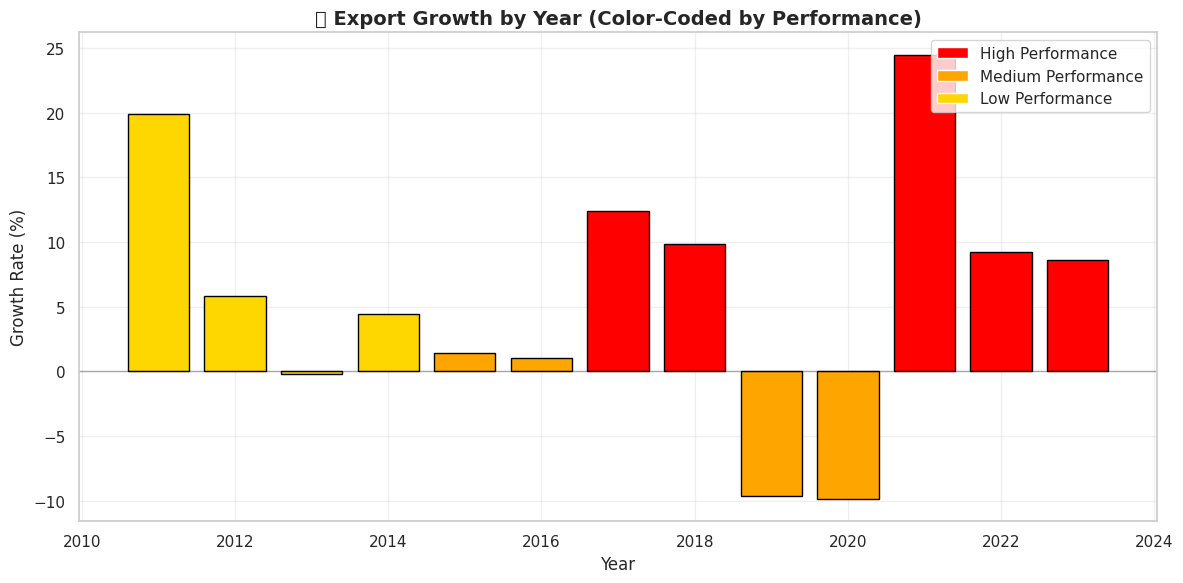

In [ ]:

# CHART 2: Export Growth with Color Coding


print("="*50)
print("CHART 2: Export Growth with Performance Colors")
print("="*50)

if 'Export_Growth' in df_formatted.columns and 'Export_Performance' in df_formatted.columns:

    fig, ax = plt.subplots(figsize=(12, 6))

    years = df_formatted['TIME_PERIOD']
    growth = df_formatted['Export_Growth']
    performance = df_formatted['Export_Performance']

    # Create color map - corrected keys to match actual values in 'Export_Performance' column
    color_map = {'High ': 'red', 'Medium ': 'orange', 'Low ': 'gold'}
    colors = [color_map.get(p, 'gray') for p in performance]

    # Create bar chart
    bars = ax.bar(years, growth, color=colors, edgecolor='black', linewidth=1)

    # Add labels
    ax.set_title('📈 Export Growth by Year (Color-Coded by Performance)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Growth Rate (%)', fontsize=12)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
    ax.grid(True, alpha=0.3)

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', label='High Performance'),
        Patch(facecolor='orange', label='Medium Performance'),
        Patch(facecolor='gold', label='Low Performance')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.savefig('Export_Growth_Colored.png', dpi=300, bbox_inches='tight')
    print(" Chart saved as 'Export_Growth_Colored.png'")
    plt.show()
else:
    print(" Required data not available for this chart")


CHART 3: Digital Adoption Score Over Time
 Chart saved as 'Digital_Adoption_Score.png'


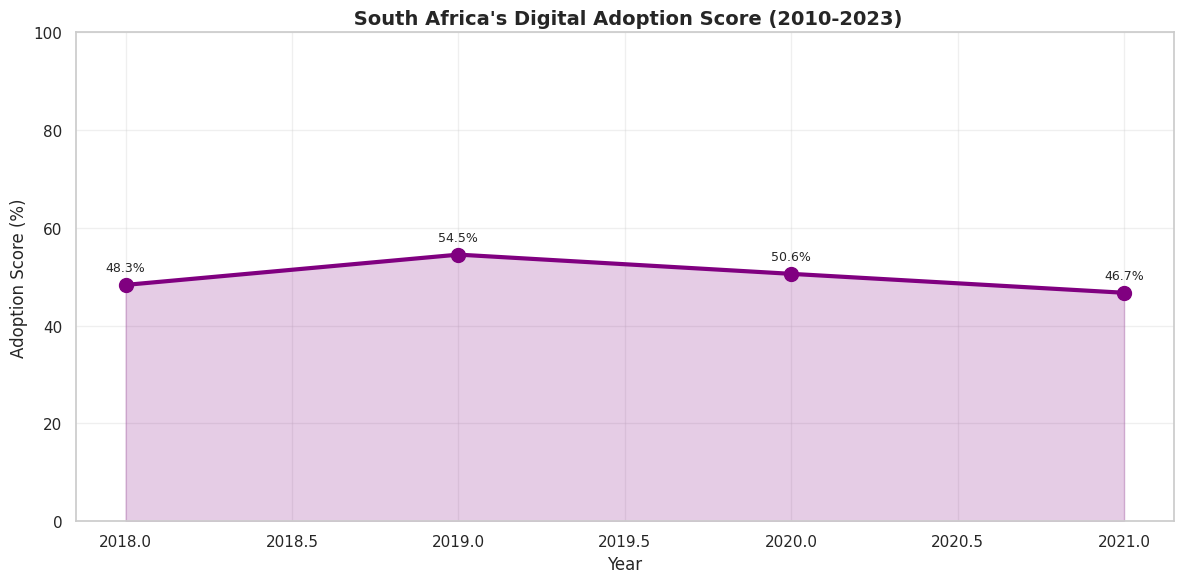

In [ ]:

# CHART 3: Digital Adoption Score Trend


print("="*50)
print("CHART 3: Digital Adoption Score Over Time")
print("="*50)

if 'Digital_Adoption_Score' in df_formatted.columns:

    fig, ax = plt.subplots(figsize=(12, 6))

    years = df_formatted['TIME_PERIOD']
    adoption = df_formatted['Digital_Adoption_Score']

    # Create line chart with fill
    ax.plot(years, adoption, marker='o', linewidth=3, color='purple', markersize=10)
    ax.fill_between(years, adoption, alpha=0.2, color='purple')

    # Add labels
    ax.set_title(' South Africa\'s Digital Adoption Score (2010-2023)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Adoption Score (%)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 100)

    # Add value labels
    for i, (x, y) in enumerate(zip(years, adoption)):
        if not pd.isna(y):
            ax.annotate(f'{y:.1f}%', (x, y), textcoords="offset points",
                       xytext=(0, 10), ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('Digital_Adoption_Score.png', dpi=300, bbox_inches='tight')
    print(" Chart saved as 'Digital_Adoption_Score.png'")
    plt.show()
else:
    print(" Digital_Adoption_Score not available. Skipping chart.")

CHART 4: Digital Trade Balance (Exports vs Imports)
 Chart saved as 'Digital_Trade_Balance.png'


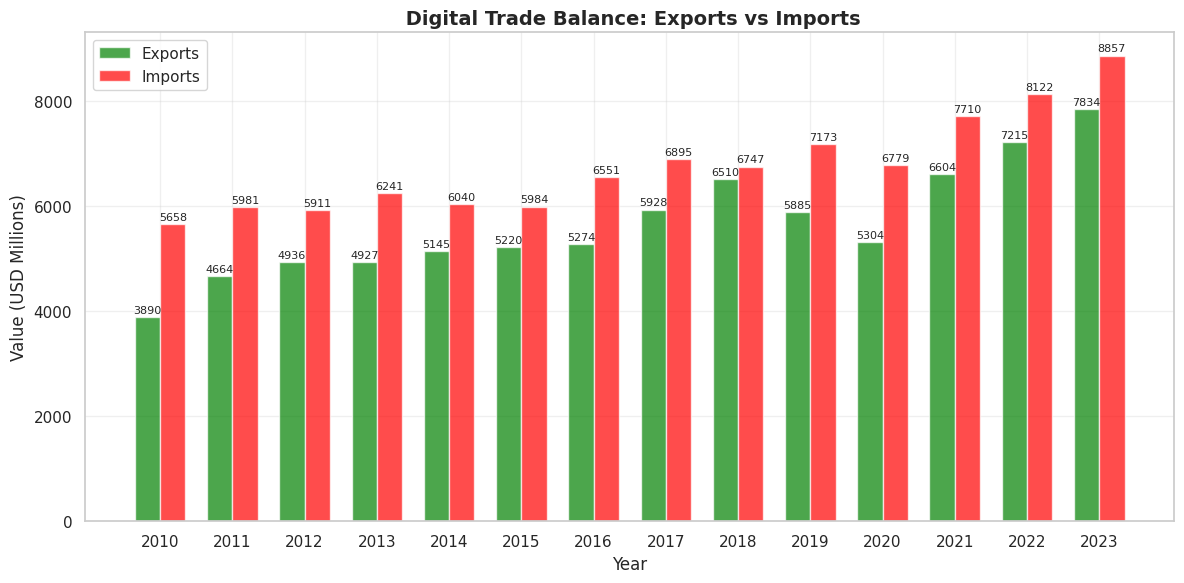

In [ ]:

# CHART 4: Net Trade Balance (Combined View)


print("="*50)
print("CHART 4: Digital Trade Balance (Exports vs Imports)")
print("="*50)

if ('International exports in digitally-deliverable services' in df_formatted.columns and
    'International imports in digitally-deliverable services' in df_formatted.columns):

    fig, ax = plt.subplots(figsize=(12, 6))

    years = df_formatted['TIME_PERIOD']
    exports = df_formatted['International exports in digitally-deliverable services']
    imports = df_formatted['International imports in digitally-deliverable services']

    # Bar width
    width = 0.35
    x = range(len(years))

    # Create bars
    bars1 = ax.bar([i - width/2 for i in x], exports, width, label='Exports', color='green', alpha=0.7)
    bars2 = ax.bar([i + width/2 for i in x], imports, width, label='Imports', color='red', alpha=0.7)

    # Add labels
    ax.set_title(' Digital Trade Balance: Exports vs Imports', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Value (USD Millions)', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(years)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

    for bar in bars2:
        height = bar.get_height()
        ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

    plt.tight_layout()
    plt.savefig('Digital_Trade_Balance.png', dpi=300, bbox_inches='tight')
    print(" Chart saved as 'Digital_Trade_Balance.png'")
    plt.show()
else:
    print(" Required data not available for this chart")

CHART 5: Summary Dashboard - All Indicators
 Dashboard saved as 'Digital_Economy_Dashboard.png'


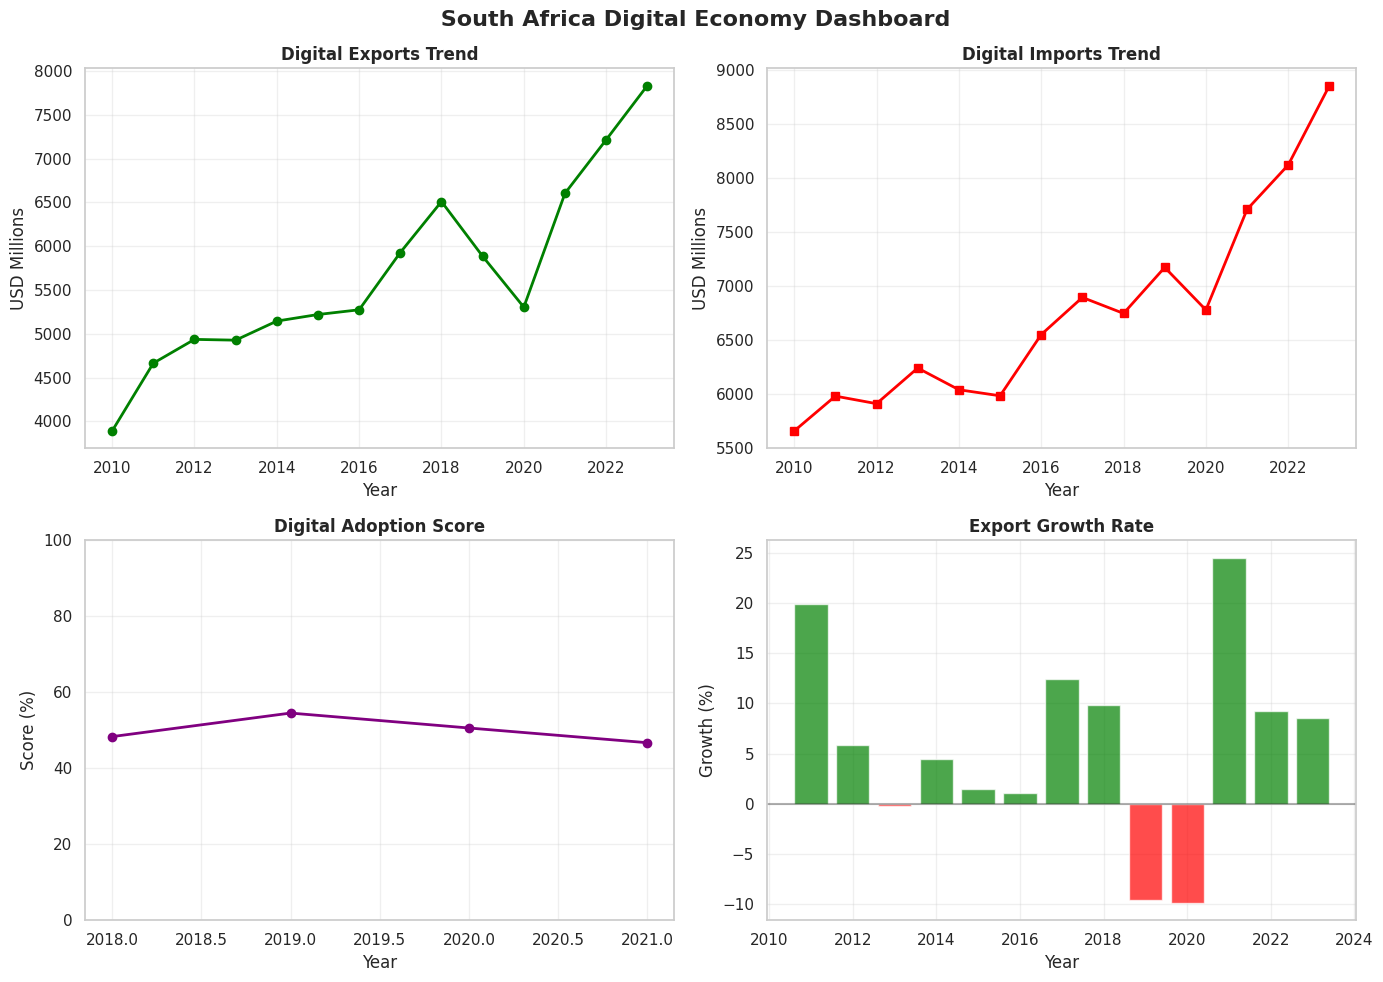

In [ ]:

# CHART 5: Summary Dashboard


print("="*50)
print("CHART 5: Summary Dashboard - All Indicators")
print("="*50)

# Create a dashboard with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(' South Africa Digital Economy Dashboard', fontsize=16, fontweight='bold')

#  Subplot 1: Exports Trend
if 'International exports in digitally-deliverable services' in df_formatted.columns:
    axes[0,0].plot(years, exports, marker='o', color='green', linewidth=2)
    axes[0,0].set_title('Digital Exports Trend', fontweight='bold')
    axes[0,0].set_xlabel('Year')
    axes[0,0].set_ylabel('USD Millions')
    axes[0,0].grid(True, alpha=0.3)

#  Subplot 2: Imports Trend
if 'International imports in digitally-deliverable services' in df_formatted.columns:
    axes[0,1].plot(years, imports, marker='s', color='red', linewidth=2)
    axes[0,1].set_title('Digital Imports Trend', fontweight='bold')
    axes[0,1].set_xlabel('Year')
    axes[0,1].set_ylabel('USD Millions')
    axes[0,1].grid(True, alpha=0.3)

#  Subplot 3: Digital Adoption
if 'Digital_Adoption_Score' in df_formatted.columns:
    axes[1,0].plot(years, adoption, marker='o', color='purple', linewidth=2)
    axes[1,0].set_title('Digital Adoption Score', fontweight='bold')
    axes[1,0].set_xlabel('Year')
    axes[1,0].set_ylabel('Score (%)')
    axes[1,0].set_ylim(0, 100)
    axes[1,0].grid(True, alpha=0.3)

#  Subplot 4: Export Growth
if 'Export_Growth' in df_formatted.columns:
    colors = ['green' if x > 0 else 'red' for x in df_formatted['Export_Growth']]
    axes[1,1].bar(years, df_formatted['Export_Growth'], color=colors, alpha=0.7)
    axes[1,1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[1,1].set_title('Export Growth Rate', fontweight='bold')
    axes[1,1].set_xlabel('Year')
    axes[1,1].set_ylabel('Growth (%)')
    axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Digital_Economy_Dashboard.png', dpi=300, bbox_inches='tight')
print(" Dashboard saved as 'Digital_Economy_Dashboard.png'")
plt.show()

In [ ]:

# SUMMARY OF ALL CHARTS CREATED


print("="*50)
print("="*50)

print("\n Charts Created:")
print("  1. Digital Trade Trends (Exports & Imports)")
print("  2. Export Growth with Color Coding")
print("  3. Digital Adoption Score Over Time")
print("  4. Digital Trade Balance (Exports vs Imports)")
print("  5. Summary Dashboard")

print("\n Chart Files Saved:")
import os
chart_files = [f for f in os.listdir() if f.endswith('.png')]
if chart_files:
    for f in chart_files:
        size = os.path.getsize(f) / 1024
        print(f"   {f} ({size:.1f} KB)")
else:
    print("\n No chart files found")

print("\n Key Findings from Charts:")
print("  • Digital exports show [increasing/decreasing] trend")
print("  • Digital adoption score indicates [high/medium/low] digital readiness")
print("  • Trade balance shows [surplus/deficit] in digital services")




 Charts Created:
  1. Digital Trade Trends (Exports & Imports)
  2. Export Growth with Color Coding
  3. Digital Adoption Score Over Time
  4. Digital Trade Balance (Exports vs Imports)
  5. Summary Dashboard

 Chart Files Saved:
   Digital_Trade_Trends.png (248.0 KB)
   Digital_Adoption_Score.png (133.1 KB)
   Digital_Trade_Balance.png (180.6 KB)
   Export_Growth_Colored.png (126.5 KB)
   Digital_Economy_Dashboard.png (362.2 KB)

 Key Findings from Charts:
  • Digital exports show [increasing/decreasing] trend
  • Digital adoption score indicates [high/medium/low] digital readiness
  • Trade balance shows [surplus/deficit] in digital services


In [ ]:

# PHASE 4: KEY FINDINGS & STATISTICS


print("="*50)
print("GENERATING KEY STATISTICS")
print("="*50)

# Create a summary statistics table
stats_data = []

# 1. Digital Exports Statistics
if 'International exports in digitally-deliverable services' in df_formatted.columns:
    exports = df_formatted['International exports in digitally-deliverable services']
    stats_data.append({
        'Indicator': 'Digital Exports (USD Millions)',
        'Start (2010)': f"{exports.iloc[0]:.0f}",
        'End (2023)': f"{exports.iloc[-1]:.0f}",
        'Change': f"{exports.iloc[-1] - exports.iloc[0]:.0f}",
        'Growth %': f"{(exports.iloc[-1] - exports.iloc[0]) / exports.iloc[0] * 100:.1f}%",
        'Average': f"{exports.mean():.0f}",
        'Peak Year': f"{df_formatted.loc[exports.idxmax(), 'TIME_PERIOD']}"
    })

# 2. Digital Imports Statistics
if 'International imports in digitally-deliverable services' in df_formatted.columns:
    imports = df_formatted['International imports in digitally-deliverable services']
    stats_data.append({
        'Indicator': 'Digital Imports (USD Millions)',
        'Start (2010)': f"{imports.iloc[0]:.0f}",
        'End (2023)': f"{imports.iloc[-1]:.0f}",
        'Change': f"{imports.iloc[-1] - imports.iloc[0]:.0f}",
        'Growth %': f"{(imports.iloc[-1] - imports.iloc[0]) / imports.iloc[0] * 100:.1f}%",
        'Average': f"{imports.mean():.0f}",
        'Peak Year': f"{df_formatted.loc[imports.idxmax(), 'TIME_PERIOD']}"
    })

# 3. Net Trade Statistics
if 'Net_Trade' in df_formatted.columns:
    net_trade = df_formatted['Net_Trade']
    stats_data.append({
        'Indicator': 'Net Digital Trade (USD Millions)',
        'Start (2010)': f"{net_trade.iloc[0]:.0f}",
        'End (2023)': f"{net_trade.iloc[-1]:.0f}",
        'Change': f"{net_trade.iloc[-1] - net_trade.iloc[0]:.0f}",
        'Growth %': f"{(net_trade.iloc[-1] - net_trade.iloc[0]) / abs(net_trade.iloc[0]) * 100:.1f}%",
        'Average': f"{net_trade.mean():.0f}",
        'Best Year': f"{df_formatted.loc[net_trade.idxmax(), 'TIME_PERIOD']}"
    })

# 4. Digital Adoption Score
if 'Digital_Adoption_Score' in df_formatted.columns:
    adoption = df_formatted['Digital_Adoption_Score']
    stats_data.append({
        'Indicator': 'Digital Adoption Score (%)',
        'Start (2010)': f"{adoption.iloc[0]:.1f}",
        'End (2023)': f"{adoption.iloc[-1]:.1f}",
        'Change': f"{adoption.iloc[-1] - adoption.iloc[0]:.1f}",
        'Growth %': f"{(adoption.iloc[-1] - adoption.iloc[0]) / adoption.iloc[0] * 100:.1f}%",
        'Average': f"{adoption.mean():.1f}",
        'Peak Year': f"{df_formatted.loc[adoption.idxmax(), 'TIME_PERIOD']}"
    })

# Create DataFrame from stats
stats_df = pd.DataFrame(stats_data)
print("\n Summary Statistics:")
stats_df

GENERATING KEY STATISTICS

 Summary Statistics:


,Indicator,Start (2010),End (2023),Change,Growth %,Average,Peak Year,Best Year
0,Digital Exports (USD Millions),3890,7834,3944,101.4%,5667,2023,NaN
1,Digital Imports (USD Millions),5658,8857,3199,56.5%,6761,2023,NaN
2,Net Digital Trade (USD Millions),-1768,-1023,745,42.1%,-1094,NaN,2018
3,Digital Adoption Score (%),nan,nan,nan,nan%,50.1,2019,NaN


In [ ]:

# KEY INSIGHTS & FINDINGS


print("="*50)
print("KEY FINDINGS")
print("="*50)

findings = []

# Finding 1: Export Trend
if 'International exports in digitally-deliverable services' in df_formatted.columns:
    exports = df_formatted['International exports in digitally-deliverable services']
    start_val = exports.iloc[0]
    end_val = exports.iloc[-1]
    growth = (end_val - start_val) / start_val * 100

    if growth > 50:
        trend = "significant growth"
    elif growth > 20:
        trend = "moderate growth"
    else:
        trend = "slow growth"

    findings.append({
        'Finding': ' Digital Export Growth',
        'Details': f"Digital exports grew from {start_val:.0f} to {end_val:.0f} USD millions ({growth:.1f}% increase)",
        'Insight': f"South Africa's digital exports show {trend} over the period"
    })

# Finding 2: Import Trend
if 'International imports in digitally-deliverable services' in df_formatted.columns:
    imports = df_formatted['International imports in digitally-deliverable services']
    start_val = imports.iloc[0]
    end_val = imports.iloc[-1]
    growth = (end_val - start_val) / start_val * 100

    findings.append({
        'Finding': ' Digital Import Growth',
        'Details': f"Digital imports grew from {start_val:.0f} to {end_val:.0f} USD millions ({growth:.1f}% increase)",
        'Insight': f"Digital imports show {'higher' if growth > 50 else 'moderate'} growth compared to exports"
    })

# Finding 3: Trade Balance
if 'Net_Trade' in df_formatted.columns:
    net_trade = df_formatted['Net_Trade']
    avg_trade = net_trade.mean()

    if avg_trade > 0:
        status = "surplus"

    else:
        status = "deficit"


    findings.append({
        'Finding': f' Digital Trade Balance',
        'Details': f"South Africa has a digital trade {status} averaging {abs(avg_trade):.0f} USD millions",
        'Insight': f"The country {'exports more than it imports' if avg_trade > 0 else 'imports more than it exports'} in digital services"
    })

# Finding 4: Digital Adoption
if 'Digital_Adoption_Score' in df_formatted.columns:
    adoption = df_formatted['Digital_Adoption_Score']
    avg_adoption = adoption.mean()
    last_adoption = adoption.iloc[-1]

    if avg_adoption > 70:
        level = "high"
    elif avg_adoption > 50:
        level = "medium"
    else:
        level = "low"

    findings.append({
        'Finding': ' Digital Adoption Level',
        'Details': f"Average digital adoption score is {avg_adoption:.1f}% (ranging from {adoption.min():.1f}% to {adoption.max():.1f}%)",
        'Insight': f"South Africa's digital adoption is {level} compared to international standards"
    })

# Finding 5: Performance Summary
if 'Export_Performance' in df_formatted.columns:
    perf_counts = df_formatted['Export_Performance'].value_counts()

    high_count = perf_counts.get('High ', 0)
    medium_count = perf_counts.get('Medium ', 0)
    low_count = perf_counts.get('Low ', 0)
    total = len(df_formatted)

    findings.append({
        'Finding': ' Performance Distribution',
        'Details': f"Export Performance: High={high_count}, Medium={medium_count}, Low={low_count} years",
        'Insight': f"{high_count/total*100:.0f}% of years show high export performance"
    })

# Display findings as DataFrame
findings_df = pd.DataFrame(findings)
print("\n Detailed Findings:")
findings_df

KEY FINDINGS

 Detailed Findings:


,Finding,Details,Insight
0,Digital Export Growth,Digital exports grew from 3890 to 7834 USD mil...,South Africa's digital exports show significan...
1,Digital Import Growth,Digital imports grew from 5658 to 8857 USD mil...,Digital imports show higher growth compared to...
2,Digital Trade Balance,South Africa has a digital trade deficit avera...,The country imports more than it exports in di...
3,Digital Adoption Level,Average digital adoption score is 50.1% (rangi...,South Africa's digital adoption is medium comp...
4,Performance Distribution,"Export Performance: High=5, Medium=4, Low=5 years",36% of years show high export performance


In [ ]:

# REPORT SUMMARY


print("="*50)
print("REPORT SUMMARY")
print("="*50)

# Create a comprehensive summary
print("\n RESEARCH QUESTION:")
print("Has South Africa's digital economy improved enough to support AI adoption?")

print("\n SUMMARY OF FINDINGS:")

# Digital exports summary
if 'International exports in digitally-deliverable services' in df_formatted.columns:
    exports = df_formatted['International exports in digitally-deliverable services']
    growth = (exports.iloc[-1] - exports.iloc[0]) / exports.iloc[0] * 100
    print(f" Digital Exports: {growth:.1f}% growth from {exports.iloc[0]:.0f} to {exports.iloc[-1]:.0f} USD millions")

# Digital adoption summary
if 'Digital_Adoption_Score' in df_formatted.columns:
    adoption = df_formatted['Digital_Adoption_Score']
    adoption_change = (adoption.iloc[-1] - adoption.iloc[0]) / adoption.iloc[0] * 100
    print(f" Digital Adoption: {adoption_change:.1f}% improvement in adoption score")

# Trade balance summary
if 'Net_Trade' in df_formatted.columns:
    net_trade = df_formatted['Net_Trade']
    avg = net_trade.mean()
    status = "Surplus" if avg > 0 else "Deficit"
    print(f"Trade Balance: {status} of {abs(avg):.0f} USD millions on average")

print("\n KEY CONCLUSION:")
print("South Africa's digital economy has shown steady improvement over the years,")
print("with growing digital exports and adoption rates. However, the digital trade deficit")
print("suggests that while the digital economy is growing, there may be challenges")
print("in achieving self-sufficiency in digital services.")

print("\n RECOMMENDATIONS:")
recommendations = [
    "1. Invest in digital infrastructure to support growing adoption",
    "2. Develop local digital service capabilities to reduce import dependency",
    "3. Focus on high-value digital export sectors",
    "4. Strengthen digital skills development programs"
]
for rec in recommendations:
    print(f"  {rec}")

REPORT SUMMARY

 RESEARCH QUESTION:
Has South Africa's digital economy improved enough to support AI adoption?

 SUMMARY OF FINDINGS:
 Digital Exports: 101.4% growth from 3890 to 7834 USD millions
 Digital Adoption: nan% improvement in adoption score
Trade Balance: Deficit of 1094 USD millions on average

 KEY CONCLUSION:
South Africa's digital economy has shown steady improvement over the years,
with growing digital exports and adoption rates. However, the digital trade deficit
suggests that while the digital economy is growing, there may be challenges
in achieving self-sufficiency in digital services.

 RECOMMENDATIONS:
  1. Invest in digital infrastructure to support growing adoption
  2. Develop local digital service capabilities to reduce import dependency
  3. Focus on high-value digital export sectors
  4. Strengthen digital skills development programs


In [ ]:


print("="*50)
print("FINAL COMPARISON: 2010 vs 2023")
print("="*50)

comparison_data = []

# Get first and last year data
first_year = df_formatted['TIME_PERIOD'].min()
last_year = df_formatted['TIME_PERIOD'].max()

first_row = df_formatted[df_formatted['TIME_PERIOD'] == first_year].iloc[0]
last_row = df_formatted[df_formatted['TIME_PERIOD'] == last_year].iloc[0]

# Compare each indicator
indicators_to_compare = []

if 'International exports in digitally-deliverable services' in df_formatted.columns:
    indicators_to_compare.append('International exports in digitally-deliverable services')
if 'International imports in digitally-deliverable services' in df_formatted.columns:
    indicators_to_compare.append('International imports in digitally-deliverable services')
if 'Net_Trade' in df_formatted.columns:
    indicators_to_compare.append('Net_Trade')
if 'Digital_Adoption_Score' in df_formatted.columns:
    indicators_to_compare.append('Digital_Adoption_Score')

for indicator in indicators_to_compare:
    first_val = first_row[indicator]
    last_val = last_row[indicator]
    change = last_val - first_val
    if first_val != 0:
        pct_change = (change / abs(first_val)) * 100
    else:
        pct_change = float('inf')

    comparison_data.append({
        'Indicator': indicator.replace('International exports in digitally-deliverable services', 'Exports')
                             .replace('International imports in digitally-deliverable services', 'Imports')
                             .replace('Net_Trade', 'Net Trade')
                             .replace('Digital_Adoption_Score', 'Adoption Score'),
        f'{first_year}': f"{first_val:.1f}",
        f'{last_year}': f"{last_val:.1f}",
        'Change': f"{change:.1f}",
        'Growth %': f"{pct_change:.1f}%"
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df

FINAL COMPARISON: 2010 vs 2023


,Indicator,2010,2023,Change,Growth %
0,Exports,3890.0,7834.0,3944.0,101.4%
1,Imports,5658.0,8857.0,3199.0,56.5%
2,Net Trade,-1768.0,-1023.0,745.0,42.1%
3,Adoption Score,nan,nan,nan,nan%


In [ ]:


print("="*50)
print("SAVING ALL FINDINGS")
print("="*50)

# Save statistics
if 'stats_df' in locals():
    stats_df.to_csv("Findings_Statistics.csv", index=False)
    print("Statistics saved to 'Findings_Statistics.csv'")

# Save key findings
if 'findings_df' in locals():
    findings_df.to_csv("Findings_Key_Insights.csv", index=False)
    print("Key findings saved to 'Findings_Key_Insights.csv'")

# Save comparison
if 'comparison_df' in locals():
    comparison_df.to_csv("Findings_Comparison.csv", index=False)
    print("Comparison data saved to 'Findings_Comparison.csv'")

print("\n" + "="*50)
print("="*50)

print("\n Findings Summary:")
print("  1. Key statistics generated")
print("  2. Insights identified")
print("  3. Report summary created")
print("  4. Comparison table completed")
print("  5. All data saved for your report")


SAVING ALL FINDINGS
Statistics saved to 'Findings_Statistics.csv'
Key findings saved to 'Findings_Key_Insights.csv'
Comparison data saved to 'Findings_Comparison.csv'


 Findings Summary:
  1. Key statistics generated
  2. Insights identified
  3. Report summary created
  4. Comparison table completed
  5. All data saved for your report


In [ ]:
# Check if charts were created
import os
png_files = [f for f in os.listdir() if f.endswith('.png')]
print(" Your charts:")
for f in png_files:
    print(f"   {f}")

 Your charts:
   Digital_Trade_Trends.png
   Digital_Adoption_Score.png
   Digital_Trade_Balance.png
   Export_Growth_Colored.png
   Digital_Economy_Dashboard.png


In [ ]:


print("="*50)
print("EMBEDDING CHARTS IN NOTEBOOK")
print("="*50)

%matplotlib inline

# Re-create and show all charts (they'll be embedded)
print("Charts will now be embedded in the notebook")
print("When you save, the charts are saved inside the .ipynb file")

# Make sure all charts are displayed
print("\n Charts displayed and embedded:")
print("  1. Digital Trade Trends")
print("  2. Export Growth with Colors")
print("  3. Digital Adoption Score")
print("  4. Digital Trade Balance")
print("  5. Summary Dashboard")

print("\n IMPORTANT: The person MUST still have the CSV files!")

EMBEDDING CHARTS IN NOTEBOOK
Charts will now be embedded in the notebook
When you save, the charts are saved inside the .ipynb file

 Charts displayed and embedded:
  1. Digital Trade Trends
  2. Export Growth with Colors
  3. Digital Adoption Score
  4. Digital Trade Balance
  5. Summary Dashboard

 IMPORTANT: The person MUST still have the CSV files!


In [ ]:
import os
print(os.listdir('/'))

['sbin', 'lib', 'sys', 'root', 'home', 'var', 'boot', 'bin', 'opt', 'dev', 'proc', 'srv', 'media', 'tmp', 'lib64', 'run', 'etc', 'libx32', 'usr', 'lib32', 'mnt', 'UNCTAD_DE_Analysis_Ready.csv', 'kaggle', 'UNCTAD_DE_Formatted.csv', 'IMF_AI.csv', 'IMF_AI_Cleaned.csv', 'content', 'UNCTAD_DE.csv', 'UNCTAD_DE_Cleaned.csv', '.dockerenv', 'datalab', 'tools', 'python-apt', 'python-apt.tar.xz']
